<a href="https://colab.research.google.com/github/Miguithub/fourier/blob/main/Fourier_BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# LIBRERIAS 1

In [ ]:
!pip install statsmodels

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

---

# DI

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


In [ ]:
btc = pd.read_parquet('/content/drive/MyDrive/1mbtc.parquet')

In [ ]:
eth = pd.read_parquet('/content/drive/MyDrive/1meth.parquet')

In [ ]:
sol = pd.read_parquet('/content/drive/MyDrive/1msol.parquet')

Check

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2442120 entries, 0 to 2442119
Data columns (total 12 columns):
 #   Column               Dtype  
---  ------               -----  
 0   timestamp            object 
 1   open                 float64
 2   high                 float64
 3   low                  float64
 4   close                float64
 5   volume               float64
 6   close_time           float64
 7   quote_asset_volume   float64
 8   num_trades           float64
 9   taker_buy_base_vol   float64
 10  taker_buy_quote_vol  float64
 11  ignore               float64
dtypes: float64(11), object(1)
memory usage: 223.6+ MB


In [ ]:
btc.tail()

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol,ignore
0,2021-01-01 00:00:00,28923.63,28961.66,28913.12,28961.66,27.457032,1.609459e+12,7.943820e+05,1292.0,16.777195,485390.826825,0.0
1,2021-01-01 00:01:00,28961.67,29017.50,28961.01,29009.91,58.477501,1.609459e+12,1.695803e+06,1651.0,33.733818,978176.468202,0.0
2,2021-01-01 00:02:00,29009.54,29016.71,28973.58,28989.30,42.470329,1.609459e+12,1.231359e+06,986.0,13.247444,384076.854453,0.0
3,2021-01-01 00:03:00,28989.68,28999.85,28972.33,28982.69,30.360677,1.609459e+12,8.800168e+05,959.0,9.456028,274083.075142,0.0
4,2021-01-01 00:04:00,28982.67,28995.93,28971.80,28975.65,24.124339,1.609459e+12,6.992262e+05,726.0,6.814644,197519.374888,0.0


In [ ]:
btc.head()

,timestamp,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_close_time,btc_quote_asset_volume,btc_num_trades,btc_taker_buy_base_vol,btc_taker_buy_quote_vol,btc_ignore
0,2021-01-01 00:00:00,28923.630859,28961.660156,28913.119141,28961.660156,27.457031,1.609459e+12,7.943821e+05,1292.0,16.777195,485390.81250,0.0
1,2021-01-01 00:01:00,28961.669922,29017.500000,28961.009766,29009.910156,58.477501,1.609459e+12,1.695803e+06,1651.0,33.733818,978176.43750,0.0
2,2021-01-01 00:02:00,29009.539062,29016.710938,28973.580078,28989.300781,42.470329,1.609459e+12,1.231359e+06,986.0,13.247444,384076.84375,0.0
3,2021-01-01 00:03:00,28989.679688,28999.849609,28972.330078,28982.689453,30.360678,1.609459e+12,8.800168e+05,959.0,9.456028,274083.06250,0.0
4,2021-01-01 00:04:00,28982.669922,28995.929688,28971.800781,28975.650391,24.124338,1.609460e+12,6.992262e+05,726.0,6.814644,197519.37500,0.0


Transformacion

In [ ]:
# import numpy as np
# import pandas as pd

# cols_to_f32 = btc.select_dtypes(include=["float64", "int64"]).columns.tolist()
# mem_before = btc.memory_usage(deep=True).sum()
# btc[cols_to_f32] = btc[cols_to_f32].astype("float32")
# mem_after = btc.memory_usage(deep=True).sum()

# print(f"Columnas convertidas a float32: {len(cols_to_f32)}")
# print(f"Memoria antes:  {mem_before/1024/1024:.2f} MB")
# print(f"Memoria después:{mem_after/1024/1024:.2f} MB")

In [ ]:
float64_cols = btc.select_dtypes(include=["float64"]).columns

btc.rename(
    columns={c: (c if c.startswith("btc_") else f"btc_{c}") for c in float64_cols},
    inplace=True
)
dupes = btc.columns[btc.columns.duplicated()].tolist()
if dupes:
    print("Advertencia: columnas duplicadas tras renombrar:", dupes)

In [ ]:
import pandas as pd
btc['timestamp'] = pd.to_datetime(btc['timestamp'], errors='coerce')

In [ ]:
# import numpy as np
# import pandas as pd

# cols_to_f32 = eth.select_dtypes(include=["float64", "int64"]).columns.tolist()
# mem_before = eth.memory_usage(deep=True).sum()
# eth[cols_to_f32] = eth[cols_to_f32].astype("float32")
# mem_after = eth.memory_usage(deep=True).sum()

# print(f"Columnas convertidas a float32: {len(cols_to_f32)}")
# print(f"Memoria antes:  {mem_before/1024/1024:.2f} MB")
# print(f"Memoria después:{mem_after/1024/1024:.2f} MB")

Columnas convertidas a float32: 9
Memoria antes:  185.37 MB
Memoria después:101.95 MB


In [ ]:
float64_cols = eth.select_dtypes(include=["float64"]).columns

eth.rename(
    columns={c: (c if c.startswith("eth_") else f"eth_{c}") for c in float64_cols},
    inplace=True
)
dupes = eth.columns[eth.columns.duplicated()].tolist()
if dupes:
    print("Advertencia: columnas duplicadas tras renombrar:", dupes)

In [ ]:
# import numpy as np
# import pandas as pd

# cols_to_f32 = sol.select_dtypes(include=["float64", "int64"]).columns.tolist()
# mem_before = sol.memory_usage(deep=True).sum()
# sol[cols_to_f32] = sol[cols_to_f32].astype("float32")
# mem_after = sol.memory_usage(deep=True).sum()

# print(f"Columnas convertidas a float32: {len(cols_to_f32)}")
# print(f"Memoria antes:  {mem_before/1024/1024:.2f} MB")
# print(f"Memoria después:{mem_after/1024/1024:.2f} MB")

In [ ]:
float64_cols = sol.select_dtypes(include=["float64"]).columns

sol.rename(
    columns={c: (c if c.startswith("sol_") else f"sol_{c}") for c in float64_cols},
    inplace=True
)
dupes = sol.columns[sol.columns.duplicated()].tolist()
if dupes:
    print("Advertencia: columnas duplicadas tras renombrar:", dupes)

In [ ]:
import pandas as pd

# =========================
# 1) Normalizar y limpiar timestamps
# =========================
def _prep(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if "timestamp" not in df.columns:
        raise KeyError(f"El DataFrame '{name}' no tiene columna 'timestamp'.")
    out = df.copy()

    # Asegurar dtype datetime64[ns] (naive)
    ts = pd.to_datetime(out["timestamp"], errors="coerce")
    # Si viene con tz, quitarla; si no, no pasa nada
    try:
        ts = ts.dt.tz_convert(None)
    except Exception:
        pass
    ts = ts.dt.tz_localize(None)
    out["timestamp"] = ts

    # Quitar nulos y duplicados de timestamp, y ordenar
    out = (
        out.dropna(subset=["timestamp"])
           .drop_duplicates(subset=["timestamp"], keep="last")
           .sort_values("timestamp")
    )
    return out

btc_ = _prep(btc, "btc")
eth_ = _prep(eth, "eth")
sol_ = _prep(sol, "sol")

# =========================
# 2) Evitar colisiones de nombres SIN prefijos/ sufijos
#    (Se preservan los nombres de ETH; se eliminan de btc/sol
#     las columnas que colisionan con ETH, excepto 'timestamp')
# =========================
overlap_btc = [c for c in btc_.columns if c != "timestamp" and c in eth_.columns]
overlap_sol = [c for c in sol_.columns if c != "timestamp" and c in eth_.columns]

btc_no_overlap = btc_.drop(columns=overlap_btc) if overlap_btc else btc_
sol_no_overlap = sol_.drop(columns=overlap_sol) if overlap_sol else sol_

# =========================
# 3) Merge anclado en ETH (timestamp principal)
# =========================
mf = (
    eth_
    .merge(btc_no_overlap, on="timestamp", how="left")
    .merge(sol_no_overlap, on="timestamp", how="left")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

In [ ]:
mf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 29 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   timestamp                datetime64[ns]
 1   eth_open                 float64       
 2   eth_high                 float64       
 3   eth_low                  float64       
 4   eth_close                float64       
 5   eth_volume               float64       
 6   eth_quote_asset_volume   float64       
 7   num_trades               int64         
 8   eth_taker_buy_base_vol   float64       
 9   eth_taker_buy_quote_vol  float64       
 10  btc_open                 float64       
 11  btc_high                 float64       
 12  btc_low                  float64       
 13  btc_close                float64       
 14  btc_volume               float64       
 15  btc_close_time           float64       
 16  btc_quote_asset_volume   float64       
 17  btc_num_trades           fl

#mf1

In [ ]:
# Mantener solo 'timestamp' y columnas cuyo nombre termine en 'close' (insensible a mayúsculas)
import pandas as pd

if 'timestamp' not in mf.columns:
    raise KeyError("mf no tiene columna 'timestamp'.")

# Asegurar timestamp válido y ordenado
mf['timestamp'] = pd.to_datetime(mf['timestamp'], errors='coerce')
mf1 = mf.dropna(subset=['timestamp']).sort_values('timestamp')

# Selección de columnas que terminan en 'close' (case-insensitive)
cols_close = [c for c in mf1.columns
              if c != 'timestamp' and c.strip().lower().endswith('close')]

# Crear nuevo mf1 con solo timestamp + closes
mf1 = mf.loc[:, ['timestamp'] + cols_close].reset_index(drop=True)
mf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[ns]
 1   eth_close  float64       
 2   btc_close  float64       
 3   sol_close  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 74.1 MB


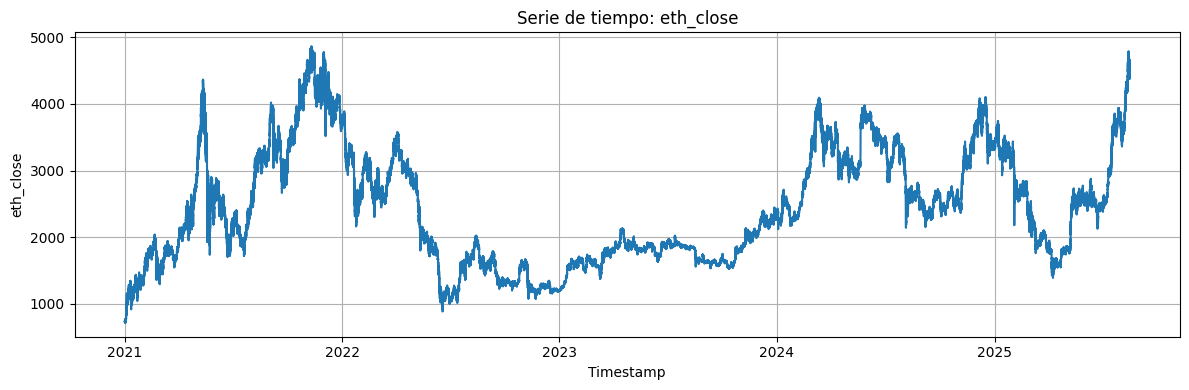

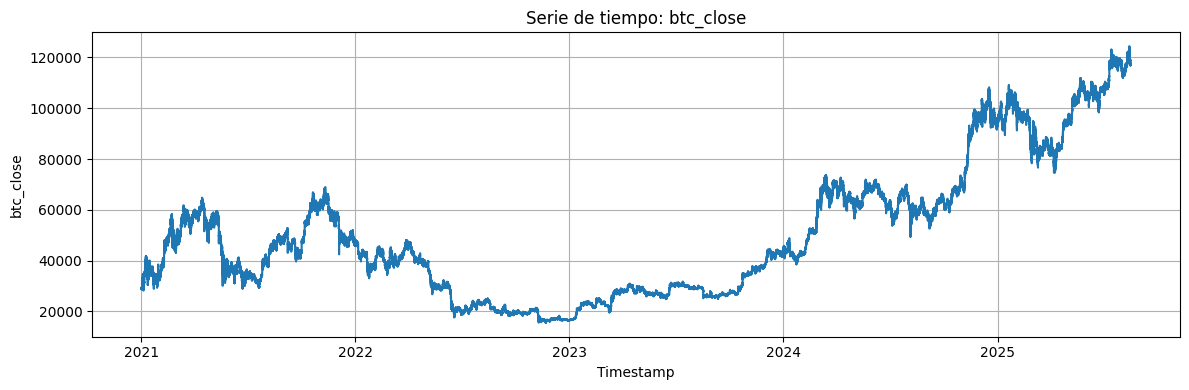

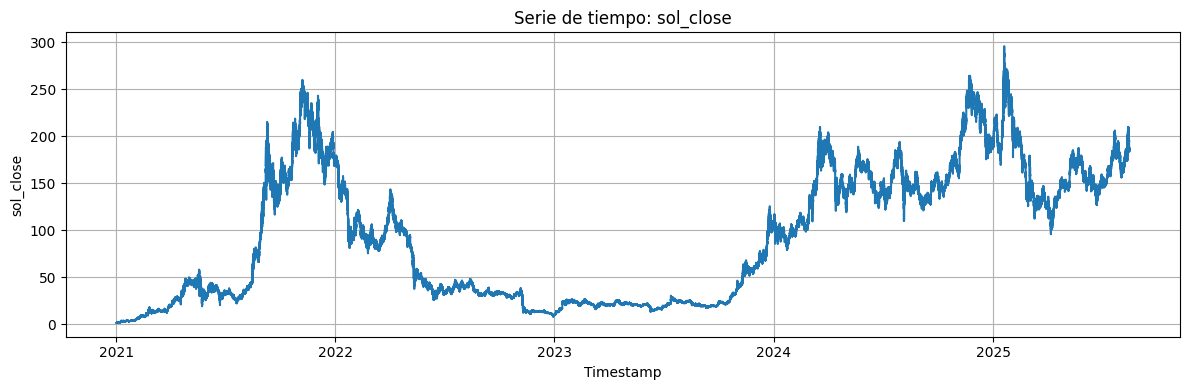

In [ ]:
import matplotlib.pyplot as plt

# Excluir la columna 'timestamp' (columna 0)
cols = mf1.columns[1:]

# Número de filas (por si querés limitar N más adelante)
N = mf1.shape[0]

# Para cada columna, graficar su serie por separado
for col in cols:
    plt.figure(figsize=(12, 4))
    plt.plot(mf1['timestamp'][:N], mf1[col][:N])
    plt.title(f'Serie de tiempo: {col}')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np

float64_cols = mf1.select_dtypes(include=["float64"]).columns
mf1[[f"{c}_ln" for c in float64_cols]] = np.log(mf1[float64_cols])

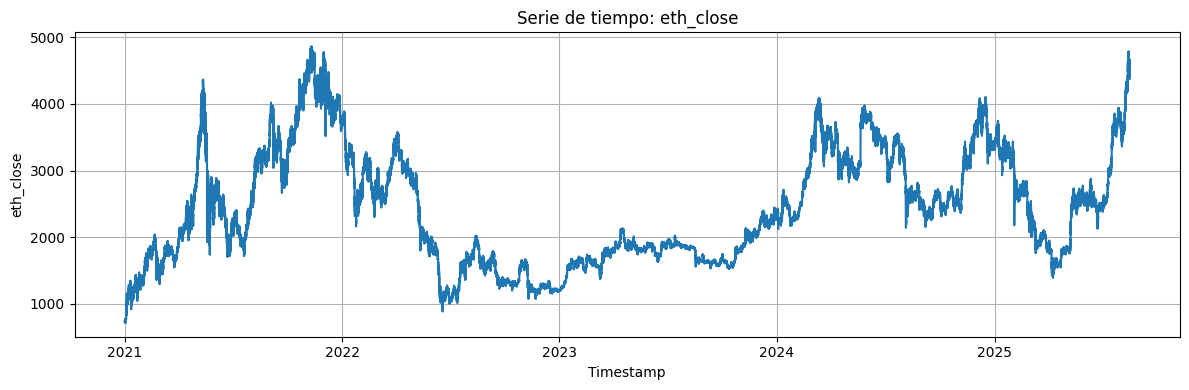

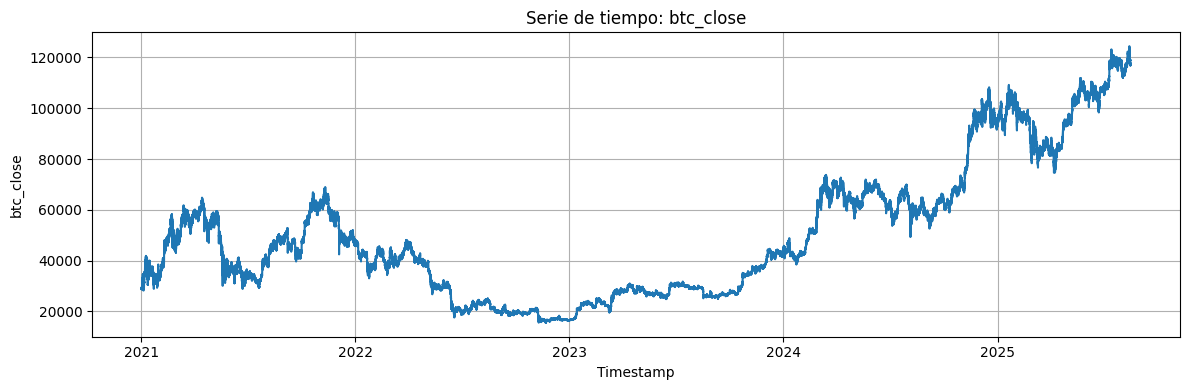

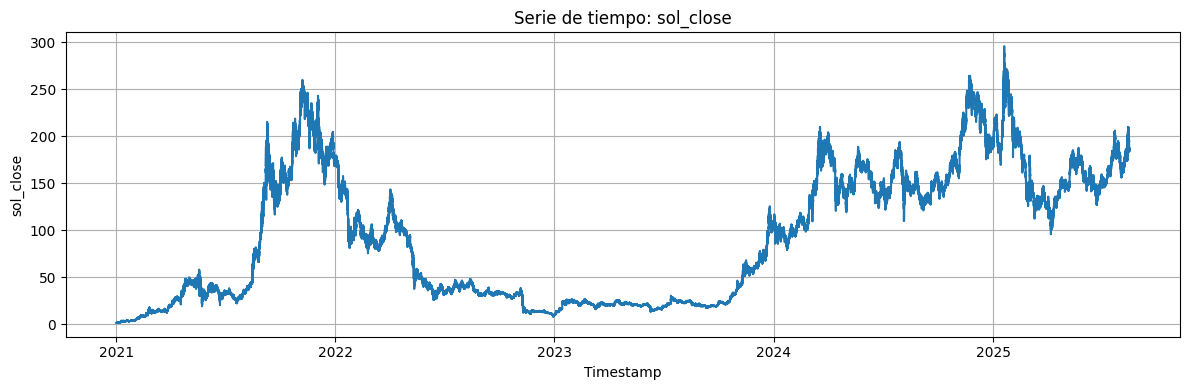

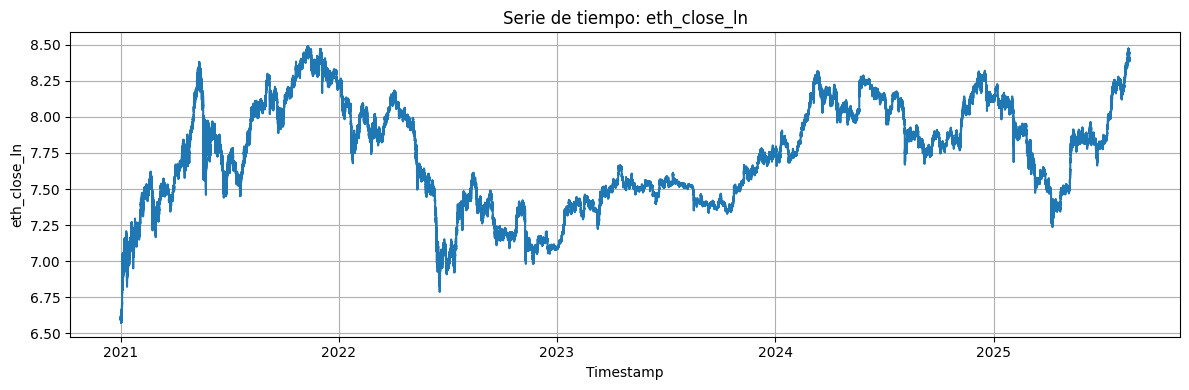

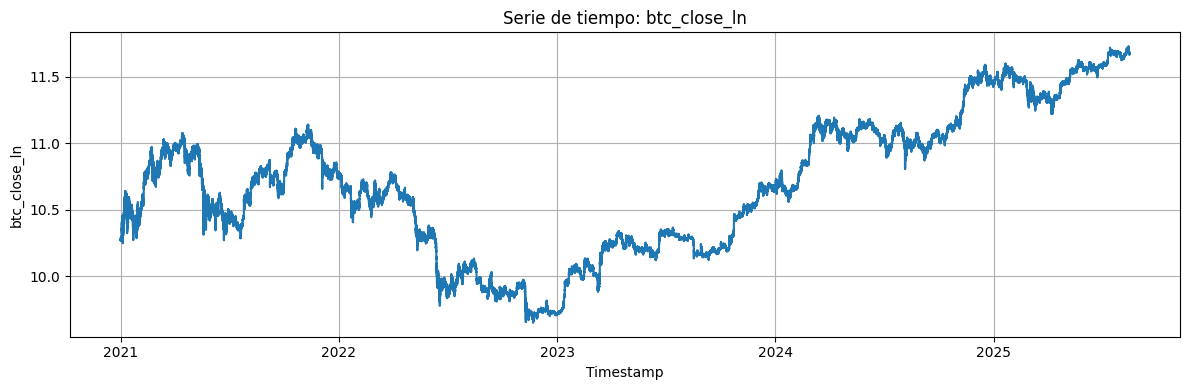

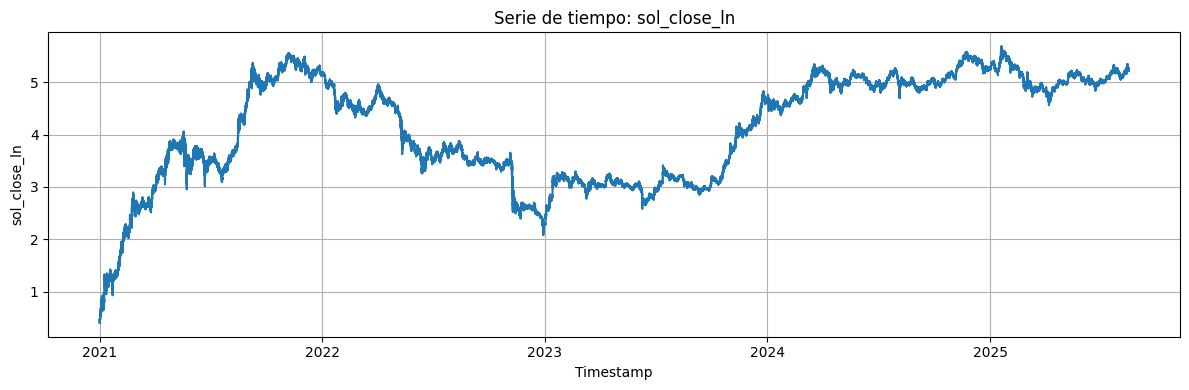

In [ ]:
import matplotlib.pyplot as plt

# Excluir la columna 'timestamp' (columna 0)
cols = mf1.columns[1:]

# Número de filas (por si querés limitar N más adelante)
N = mf1.shape[0]

# Para cada columna, graficar su serie por separado
for col in cols:
    plt.figure(figsize=(12, 4))
    plt.plot(mf1['timestamp'][:N], mf1[col][:N])
    plt.title(f'Serie de tiempo: {col}')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Opción robusta: sanear nombres y diferenciar ---
import re

# 1) Sanear nombres (espacios, zero-width, normalizar unicode)
mf1.columns = (mf1.columns
                .str.normalize('NFKC')
                .str.replace(r'[\u200b\u200c\u200d\uFEFF]', '', regex=True)
                .str.strip())

# 2) Asegurar orden temporal (opcional pero recomendable)
if 'timestamp' in mf.columns:
    mf1 = mf1.sort_values('timestamp')

# 3) Diferencias
cols = ['eth_close_ln', 'btc_close_ln', 'sol_close_ln']
presentes = [c for c in cols if c in mf1.columns]
mf1[[f"{c}_diff" for c in presentes]] = mf1[presentes].diff()

In [ ]:
mf1['dia'] = (((pd.to_datetime(mf1['timestamp'], errors='coerce').dt.dayofweek + 1) % 7) + 1).astype('int32')
mf1['hora_str'] = mf1['timestamp'].dt.strftime('%H:%M:%S')
mf1['hora_time'] = mf1['timestamp'].dt.time
mf1['hour']   = mf1['timestamp'].dt.hour
mf1['minute'] = mf1['timestamp'].dt.minute

In [ ]:
mf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 15 columns):
 #   Column             Dtype         
---  ------             -----         
 0   timestamp          datetime64[ns]
 1   eth_close          float64       
 2   btc_close          float64       
 3   sol_close          float64       
 4   eth_close_ln       float64       
 5   btc_close_ln       float64       
 6   sol_close_ln       float64       
 7   eth_close_ln_diff  float64       
 8   btc_close_ln_diff  float64       
 9   sol_close_ln_diff  float64       
 10  dia                int32         
 11  hora_str           object        
 12  hora_time          object        
 13  hour               int32         
 14  minute             int32         
dtypes: datetime64[ns](1), float64(9), int32(3), object(2)
memory usage: 250.2+ MB


In [ ]:
# split 80/20 por tiempo (último 20% = test)
mf1_ = mf1.sort_values("timestamp")
n = len(mf1_)
cut = int(0.8 * n)

mf1_train = mf1_.iloc[:cut].copy()
mf1_test  = mf1_.iloc[cut:].copy()

print(len(mf1_train), len(mf1_test))

1943717 485930


In [ ]:
mf1_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1943717 entries, 0 to 1943716
Data columns (total 20 columns):
 #   Column             Dtype         
---  ------             -----         
 0   timestamp          datetime64[ns]
 1   eth_close          float64       
 2   btc_close          float64       
 3   sol_close          float64       
 4   eth_close_ln       float64       
 5   btc_close_ln       float64       
 6   sol_close_ln       float64       
 7   eth_close_ln_diff  float64       
 8   btc_close_ln_diff  float64       
 9   sol_close_ln_diff  float64       
 10  dia                int32         
 11  hora_str           object        
 12  hora_time          object        
 13  hour               int32         
 14  minute             int32         
 15  Vhat_spot_Fourier  float32       
 16  SD_30              float64       
 17  VB30               float64       
 18  SD_480             float64       
 19  VB8h               float64       
dtypes: datetime64[ns](1), fl

In [ ]:
mf1.tail()

,timestamp,eth_close,btc_close,sol_close,eth_close_ln,btc_close_ln,sol_close_ln,eth_close_ln_diff,btc_close_ln_diff,sol_close_ln_diff,fft_var_eth,fft_cov_eth_sol,fft_cov_btc_eth,fft_var_btc,fft_cov_btc_sol,fft_var_sol
2429642,2025-08-15 23:55:00,4429.750000,117259.929688,185.550003,8.396098,11.672149,5.223324,0.000847,0.000205,0.000323,8.049665e-12,6.193427e-12,3.006464e-12,1.287553e-12,2.299122e-12,6.130655e-12
2429643,2025-08-15 23:56:00,4434.799805,117323.468750,185.639999,8.397238,11.672690,5.223809,0.001140,0.000542,0.000485,8.032579e-12,6.178232e-12,3.001072e-12,1.285766e-12,2.293705e-12,6.117967e-12
2429644,2025-08-15 23:57:00,4434.680176,117323.468750,185.649994,8.397211,11.672690,5.223863,-0.000027,0.000000,0.000054,8.015001e-12,6.162629e-12,2.995461e-12,1.283892e-12,2.288117e-12,6.105006e-12
2429645,2025-08-15 23:58:00,4436.740234,117322.640625,185.669998,8.397676,11.672683,5.223971,0.000464,-0.000008,0.000108,7.996934e-12,6.146621e-12,2.989630e-12,1.281931e-12,2.282360e-12,6.091776e-12
2429646,2025-08-15 23:59:00,4439.470215,117342.046875,185.720001,8.398291,11.672849,5.224240,0.000615,0.000166,0.000269,7.978382e-12,6.130215e-12,2.983581e-12,1.279885e-12,2.276436e-12,6.078282e-12


**Correlaciones** primarias

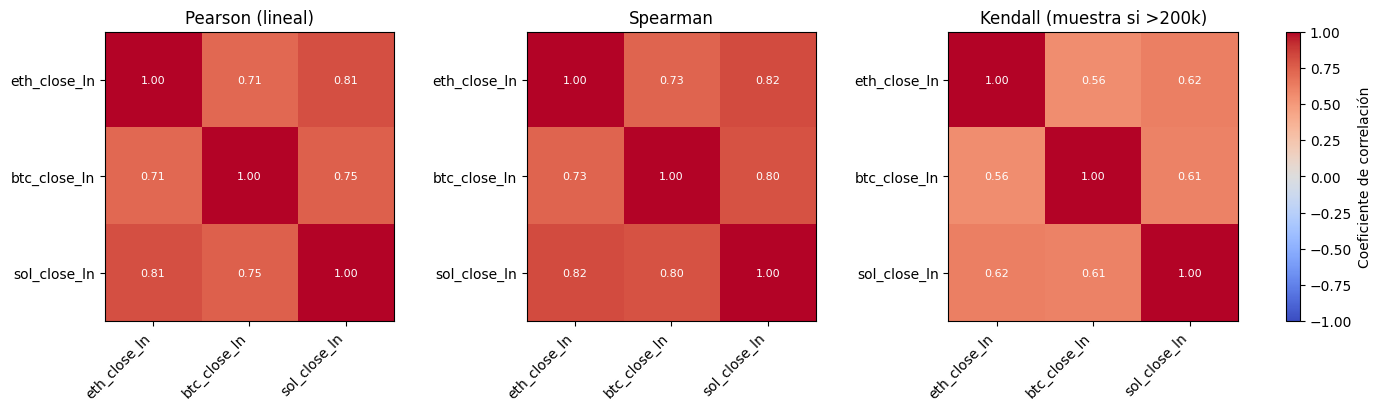

In [ ]:
# Correlaciones (Pearson/Spearman/Kendall) y plot para mf1[['eth_close_ln','btc_close_ln','sol_close_ln']]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = mf1.copy()

# Asegurar columnas
cols = ['eth_close_ln', 'btc_close_ln', 'sol_close_ln']
missing = [c for c in cols if c not in df.columns]
if missing:
    raise KeyError(f"Faltan columnas en mf1: {missing}")

# Datos limpios
X = (df[cols]
     .apply(pd.to_numeric, errors='coerce')
     .dropna())

# Matrices de correlación
pearson  = X.corr(method='pearson')
spearman = X.corr(method='spearman')

# Kendall puede ser muy pesado en millones de filas: muestreamos
kendall_sample = X.sample(n=min(200_000, len(X)), random_state=42) if len(X) > 200_000 else X
kendall = kendall_sample.corr(method='kendall')

# Plot helper
def plot_heat(ax, M, title, labels):
    im = ax.imshow(M.values, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    ax.set_title(title)
    for (i, j), v in np.ndenumerate(M.values):
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.5 else 'black', fontsize=8)
    return im

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
labels = cols

im = plot_heat(axes[0], pearson,  'Pearson (lineal)', labels)
plot_heat(axes[1], spearman, 'Spearman', labels)
plot_heat(axes[2], kendall,  'Kendall (muestra si >200k)', labels)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Coeficiente de correlación')

plt.show()

# BTC V_hat

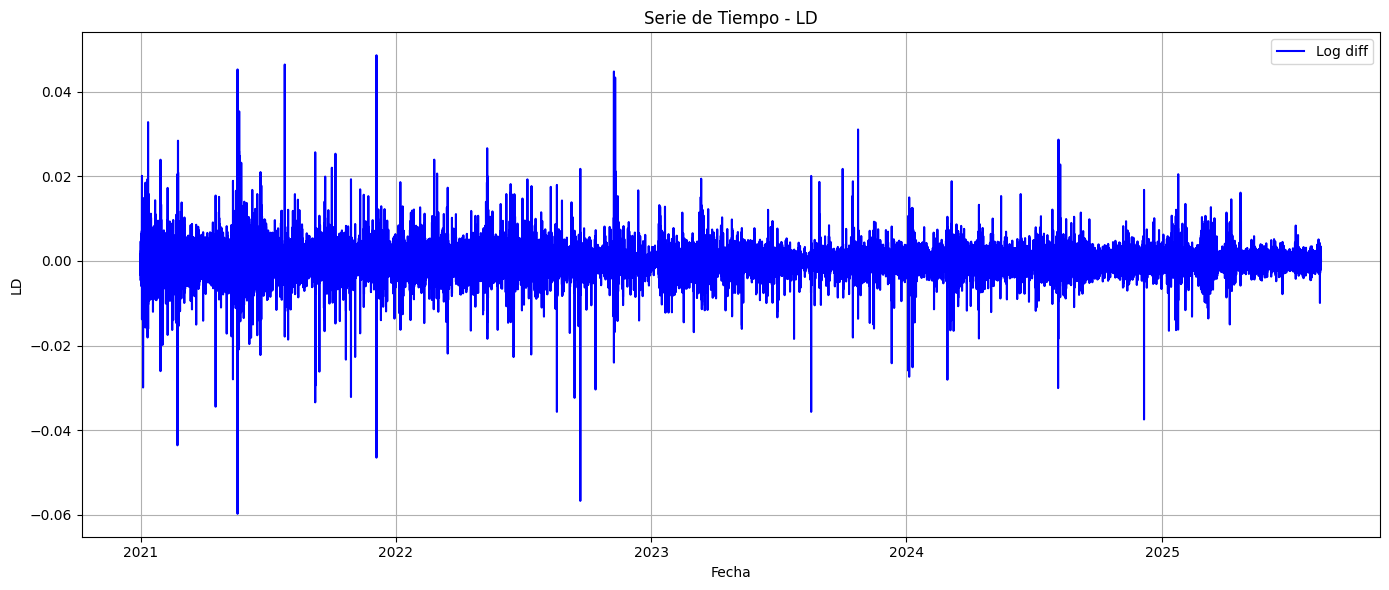

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(mf1["timestamp"], mf1["btc_close_ln_diff"], label="Log diff", color="blue")
plt.title("Serie de Tiempo - LD")
plt.xlabel("Fecha")
plt.ylabel("LD")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

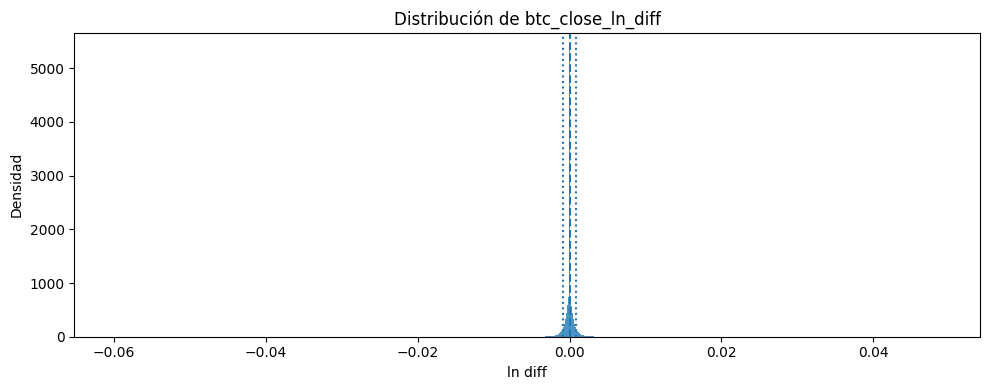

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = mf1["btc_close_ln_diff"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.hist(x, bins="auto", density=True, alpha=0.8)
plt.axvline(x.mean(), linestyle="--")
plt.axvline(x.mean()+x.std(), linestyle=":")
plt.axvline(x.mean()-x.std(), linestyle=":")
plt.title("Distribución de btc_close_ln_diff")
plt.xlabel("ln diff"); plt.ylabel("Densidad")
plt.tight_layout(); plt.show()

In [ ]:
# === Ventana mínima con "estabilidad" intrabloque (toda la serie) ===
import numpy as np
import pandas as pd

# r: pd.Series o np.ndarray de retornos 1-min
# candidates: lista de longitudes de ventana (en minutos)
# stride: paso entre comienzos de ventana para abaratar cómputo (p.ej., 5 → evalúa cada 5 min)
# rules: umbrales de decisión
def find_min_stable_window(r, candidates=None, stride=15,
                           d_median_thr=0.10, d_p80_thr=0.20, pass_rate_thr=0.70, eps=1e-15,
                           robust=False):
    # --- datos ---
    if isinstance(r, pd.Series): r = r.to_numpy(dtype=float)
    r = np.asarray(r, float)
    r[~np.isfinite(r)] = 0.0
    n = r.size

    # --- proxy de varianza por minuto ---
    if robust:
        # Bipower minuto: |r_t|*|r_{t-1}|  (inicia en t=1)
        absr = np.abs(r)
        bp = absr * np.roll(absr, 1)
        bp[0] = 0.0
        v = (np.pi/2.0) * bp
    else:
        v = r*r

    # cumsum para sumas O(1)
    V = np.concatenate(([0.0], np.cumsum(v)))

    # candidatos por defecto: múltiplos de 30 min (30..480), puedes ampliar
    if candidates is None:
        candidates = list(range(30, 481, 30))

    rows = []
    for L in candidates:
        if L < 4 or L > n:  # triviales
            rows.append((L, np.nan, np.nan, np.nan, 0.0, 0))
            continue
        h = L // 2
        if h == 0:
            rows.append((L, np.nan, np.nan, np.nan, 0.0, 0))
            continue

        # índices de ventanas con stride
        starts = np.arange(0, n - L + 1, stride, dtype=int)
        # sumas en mitades por cumsum
        S1 = V[starts + h] - V[starts]
        S2 = V[starts + L] - V[starts + h]
        den = S1 + S2 + eps
        d = np.abs(S1 - S2) / den

        # métricas
        valid = np.isfinite(d)
        if not np.any(valid):
            rows.append((L, np.nan, np.nan, np.nan, 0.0, 0))
            continue
        d = d[valid]
        d_med = float(np.median(d))
        d_p80 = float(np.quantile(d, 0.80))
        # regla por-ventana: d <= d_p80_thr (más dura que la mediana)
        passed = (d <= d_p80_thr)
        pass_rate = float(np.mean(passed))

        # dictamen de L: pasa si mediana y p80 bajo y tasa de aprobación suficiente
        ok = (d_med <= d_median_thr) and (d_p80 <= d_p80_thr) and (pass_rate >= pass_rate_thr)
        rows.append((L, d_med, d_p80, pass_rate, float(ok), d.size))

    df = pd.DataFrame(rows, columns=["L", "d_median", "d_p80", "pass_rate", "pass_flag", "num_windows"])
    # elegir el L mínimo que pasa
    ok_df = df[df["pass_flag"] == 1.0]
    L_star = int(ok_df["L"].min()) if not ok_df.empty else None
    return L_star, df


r = mf1["btc_close_ln_diff"].astype(float)   # toda tu serie (>2.4M)
L_star, summary = find_min_stable_window(r, candidates=None, stride=5,
                                         d_median_thr=0.10, d_p80_thr=0.20, pass_rate_thr=0.70,
                                         robust=False)
print("L* (min ventana estable):", L_star)
print(summary)


L* (min ventana estable): None
      L  d_median     d_p80  pass_rate  pass_flag  num_windows
0    30  0.262118  0.482829   0.390816        0.0       485924
1    60  0.230813  0.434338   0.439860        0.0       485918
2    90  0.221862  0.421844   0.456486        0.0       485912
3   120  0.221548  0.421092   0.457689        0.0       485906
4   150  0.223154  0.423608   0.454266        0.0       485900
5   180  0.225760  0.427294   0.449592        0.0       485894
6   210  0.228492  0.431330   0.444360        0.0       485888
7   240  0.231316  0.435539   0.439658        0.0       485882
8   270  0.233484  0.439612   0.435691        0.0       485876
9   300  0.235769  0.443114   0.432387        0.0       485870
10  330  0.237550  0.446266   0.429217        0.0       485864
11  360  0.239160  0.449261   0.427007        0.0       485858
12  390  0.240389  0.452066   0.425251        0.0       485852
13  420  0.242144  0.455253   0.422875        0.0       485846
14  450  0.244047  0.457

In [ ]:
# === Ventana mínima estable con L en [5, 240] min y datos a 1 min ===
import numpy as np
import pandas as pd

def find_min_stable_window(r, candidates=None, stride=1,
                           d_median_thr=0.10, d_p80_thr=0.20, pass_rate_thr=0.70,
                           eps=1e-15, robust=False):
    """
    r: Serie de retornos a 1 minuto (np.ndarray o pd.Series)
    candidates: longitudes L (min). Default: 5..240 paso 1.
    stride: paso entre comienzos de ventana (1 = cada minuto).
    """
    if isinstance(r, pd.Series): r = r.to_numpy(dtype=float)
    r = np.asarray(r, float)
    r[~np.isfinite(r)] = 0.0
    n = r.size

    # proxy de varianza por minuto
    if robust:
        absr = np.abs(r)
        bp = absr * np.roll(absr, 1); bp[0] = 0.0
        v = (np.pi/2.0) * bp
    else:
        v = r*r

    V = np.concatenate(([0.0], np.cumsum(v)))

    # L en 5..240 (minutos)
    if candidates is None:
        candidates = list(range(5, 241, 1))

    rows = []
    for L in candidates:
        if L < 4 or L > n:
            rows.append((L, np.nan, np.nan, np.nan, 0.0, 0))
            continue
        h = L // 2
        if h == 0:
            rows.append((L, np.nan, np.nan, np.nan, 0.0, 0))
            continue

        starts = np.arange(0, n - L + 1, stride, dtype=int)

        S1 = V[starts + h] - V[starts]
        S2 = V[starts + L] - V[starts + h]
        den = S1 + S2 + eps
        d = np.abs(S1 - S2) / den
        d = d[np.isfinite(d)]
        if d.size == 0:
            rows.append((L, np.nan, np.nan, np.nan, 0.0, 0))
            continue

        d_med = float(np.median(d))
        d_p80 = float(np.quantile(d, 0.80))
        pass_rate = float(np.mean(d <= d_p80_thr))
        ok = (d_med <= d_median_thr) and (d_p80 <= d_p80_thr) and (pass_rate >= pass_rate_thr)

        rows.append((L, d_med, d_p80, pass_rate, float(ok), d.size))

    df = pd.DataFrame(rows, columns=["L", "d_median", "d_p80", "pass_rate", "pass_flag", "num_windows"])
    ok_df = df[df["pass_flag"] == 1.0]
    L_star = int(ok_df["L"].min()) if not ok_df.empty else None
    return L_star, df


r = mf1["btc_close_ln_diff"].astype(float).to_numpy()
L_star, summary = find_min_stable_window(r, candidates=None, stride=1,
                                         d_median_thr=0.10, d_p80_thr=0.20, pass_rate_thr=0.70,
                                         robust=False)
print("L* (min ventana estable, min):", L_star)
print(summary)

L* (min ventana estable, min): None
       L  d_median     d_p80  pass_rate  pass_flag  num_windows
0      5  0.521957  0.828557   0.191199        0.0      2429643
1      6  0.458115  0.755784   0.220580        0.0      2429642
2      7  0.441738  0.739212   0.230124        0.0      2429641
3      8  0.406121  0.691195   0.251601        0.0      2429640
4      9  0.394857  0.678863   0.259935        0.0      2429639
..   ...       ...       ...        ...        ...          ...
231  236  0.230755  0.435147   0.440293        0.0      2429412
232  237  0.230244  0.434963   0.441401        0.0      2429411
233  238  0.231000  0.435412   0.439973        0.0      2429410
234  239  0.230455  0.435222   0.441121        0.0      2429409
235  240  0.231168  0.435623   0.439632        0.0      2429408

[236 rows x 6 columns]


#MIapx

In [ ]:
# Definir las ventanas para calcular volatilidad
ventanas_vol_1m = {
    "10": 10,   # Antes 2 * 5
    "15": 15,   # Antes 3 * 5
    "30": 30,   # Antes 6 * 5
    "1h": 60,   # Antes 12 * 5 (60 ventanas de 1 minuto en 1 hora)
    "2h": 120,  # Antes 24 * 5
    "4h": 240,  # Antes 48 * 5
    "6h": 360,  # Antes 72 * 5
    "8h": 480,  # Antes 96 * 5
    "12h": 720, # Antes 144 * 5
    "1d": 1440, # Antes 288 * 5 (1440 ventanas de 1 minuto en 1 día)
    "3d": 4320, # Antes 864 * 5
    "4d": 5760, # Antes 1152 * 5
    "5d": 7200, # Antes 1440 * 5
    "1s": 10800, # Antes 2160 * 5
    "2s": 21600, # Antes 4320 * 5
    "1m": 45660, # Antes 9132 * 5. *Nota: Este valor parece ser de un periodo más largo, lo mantengo proporcional.*
    "2m": 91320, # Antes 18264 * 5
    "3m": 136845, # Antes 27369 * 5
    "4m": 182640, # Antes 36528 * 5
    "5m": 228300, # Antes 45660 * 5
    "6m": 273960, # Antes 54792 * 5
    "9m": 410940, # Antes 82188 * 5
    "1a": 547875, # Antes 109575 * 5
    "2a": 1095750, # Antes 219150 * 5
    "3a": 1643625, # Antes 328725 * 5
    "4a": 2191500  # Antes 438300 * 5
}



# Calcular SD y Volatilidad (VB) para cada ventana
for nombre, ventana in ventanas_vol.items():
    sd_col = f"SD_{ventana}"
    vb_col = f"VB{nombre}"

    mf1[sd_col] = mf1["btc_close_ln"].rolling(window=ventana, min_periods=ventana).std()
    mf1[vb_col] = mf1[sd_col] * np.sqrt(ventana)


In [ ]:
import numpy as np

# Generar ruido blanco con media 0 y desviación estándar 1
np.random.seed(42)  # Para reproducibilidad
mf1['RB'] = np.random.normal(loc=0, scale=1, size=len(mf1))

In [ ]:
import numpy as np, pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mutual_info_score

# 1) Armar y alinear datos
cols = ["VB30","RB","VB10","VB15","VB1h","VB2h","VB4h","VB6h","VB8h","VB12h",
        "VB1d","VB3d","VB4d","VB5d","VB1s","VB2s","VB1m","VB2m","VB3m","VB4m",
        "VB5m","VB6m","VB9m","VB1a","VB2a","VB3a","VB4a"]
df = mf1[cols].copy()

# 2) Limpieza y checks básicos
df = df.replace([np.inf,-np.inf], np.nan).dropna()
stats = df.agg(['std','nunique']).T.sort_values('std')
print("STD y nº de valores únicos por variable:\n", stats.head(10))  # ¿constantes?
print("Spearman con VB30:\n", df.corr(method='spearman')['VB30'].sort_values())

# 3) Transformación estable (variancias positivas)
def stab(x):
    x = np.asarray(x, float)
    x = np.where(x<=0, np.nan, x)
    x = np.log(x)   # log sin +1 si ya es >0
    return x

df_t = df.apply(stab).dropna()
y = df_t['VB30'].values

def mi_knn(x, y, k=5):
    x = np.asarray(x, float).reshape(-1,1)
    return float(mutual_info_regression(x, y, n_neighbors=k, random_state=0)[0])

mis = []
for c in cols:
    if c=="VB30":
        continue
    if df_t[c].std() == 0 or np.isclose(df_t[c].std(),0):
        mis.append((c, 0.0, "std≈0"))
        continue
    mis.append((c, mi_knn(df_t[c].values, y, k=5), "knn5"))

print("MI kNN (k=5) vs VB30:")
for c,v,tag in mis:
    print(f"{c:6s}  {v:.6f}  [{tag}]")

# 4) Fallback discreto por cuantiles (robusto a ties)
def mi_discrete_q(x, y, q=20):
    xq = pd.qcut(x, q=q, duplicates='drop').codes
    yq = pd.qcut(y, q=q, duplicates='drop').codes
    return float(mutual_info_score(xq, yq))

print("\nMI discreta (q=20) vs VB30:")
for c in cols:
    if c=="VB30":
        continue
    try:
        v = mi_discrete_q(df_t[c].values, y, q=20)
    except Exception:
        v = np.nan
    print(f"{c:6s}  {v:.6f}")

# 5) Si aún sale 0: romper empates con jitter mínimo y repetir kNN
rng = np.random.default_rng(123)
y_j = y + rng.normal(0, 1e-9, size=y.shape)
print("\nMI kNN con jitter en VB30:")
for c in cols:
    if c=="VB30":
        continue
    x = df_t[c].values
    v = mi_knn(x, y_j, k=5)
    print(f"{c:6s}  {v:.6f}")


STD y nº de valores únicos por variable:
             std    nunique
VB10   0.000844  1970438.0
VB15   0.000959  1980568.0
VB30   0.001254  1983377.0
VB1h   0.001687  1984242.0
VB2h   0.002295  1984511.0
VB4h   0.003130  1984856.0
VB6h   0.003751  1985074.0
VB8h   0.004262  1985201.0
VB12h  0.005090  1985466.0
VB1d   0.006846  1985989.0
Spearman con VB30:
 RB      -0.000219
VB4a     0.229461
VB3a     0.241983
VB2a     0.284986
VB1a     0.329907
VB9m     0.339506
VB6m     0.361421
VB5m     0.361799
VB4m     0.376457
VB3m     0.399939
VB2m     0.424240
VB1m     0.462297
VB2s     0.484866
VB1s     0.541595
VB4d     0.564244
VB5d     0.574050
VB3d     0.577755
VB10     0.625163
VB1d     0.687114
VB12h    0.737020
VB8h     0.761974
VB6h     0.778635
VB4h     0.800846
VB15     0.811119
VB2h     0.843592
VB1h     0.901426
VB30     1.000000
Name: VB30, dtype: float64
MI kNN (k=5) vs VB30:
RB      0.000000  [knn5]
VB10    0.417152  [knn5]
VB15    0.809846  [knn5]
VB1h    1.027999  [knn5]
VB2h  

## FAOB

**Fourier Asymptotic Optimization Battery (FAOB)** This block is made following the Manciano(2022) paper about fourier stimatiors, so its about the minimization of the C-amise, Coinditioneted asympthoti integrated squart error, looking for a first aproximation to the parameters N, M and n to make the estimation by fourier.

###n

se debe seleccionar un d: d=<t y t E [0.2,0.35]

n = 21000

In [ ]:
import numpy as np
import pandas as pd

n = 21000
h = n // 2  # 1440
r = mf1["btc_close_ln_diff"].astype(float)

# Realized variance de cada mitad vía sumas móviles de r^2
sq = r * r
sh = sq.rolling(window=h, min_periods=h).sum()  # suma de cuadrados en h

rv1 = sh.shift(h)   # primera mitad de la ventana n
rv2 = sh            # segunda mitad de la ventana n
den = rv1 + rv2

# d = |RV1 - RV2| / (RV1 + RV2), evitando división por 0
d = (rv1 - rv2).abs().div(den)
d = d.replace([np.inf, -np.inf], np.nan)
d.name = f"drift_d_{n}"

# guardar en el DataFrame
mf1[d.name] = d

# métricas pedidas
print("Ventanas válidas:", d.count())
print(f"Media(d):   {d.mean(skipna=True):.6f}")
print(f"Mediana(d): {d.median(skipna=True):.6f}")


Ventanas válidas: 2408647
Media(d):   0.226673
Mediana(d): 0.186179


n = 2880

In [ ]:
import numpy as np
import pandas as pd

n = 2880
h = n // 2  # 1440
r = mf1["btc_close_ln_diff"].astype(float)

# Realized variance de cada mitad vía sumas móviles de r^2
sq = r * r
sh = sq.rolling(window=h, min_periods=h).sum()  # suma de cuadrados en h

rv1 = sh.shift(h)   # primera mitad de la ventana n
rv2 = sh            # segunda mitad de la ventana n
den = rv1 + rv2

# d = |RV1 - RV2| / (RV1 + RV2), evitando división por 0
d = (rv1 - rv2).abs().div(den)
d = d.replace([np.inf, -np.inf], np.nan)
d.name = f"drift_d_{n}"

# guardar en el DataFrame
mf1[d.name] = d

# métricas pedidas
print("Ventanas válidas:", d.count())
print(f"Media(d):   {d.mean(skipna=True):.6f}")
print(f"Mediana(d): {d.median(skipna=True):.6f}")


Ventanas válidas: 2422447
Media(d):   0.264331
Mediana(d): 0.234393


n = 1440

In [ ]:
import numpy as np
import pandas as pd

n = 1440
h = n // 2
r = mf1["btc_close_ln_diff"].astype(float)

# Realized variance de cada mitad vía sumas móviles de r^2
sq = r * r
sh = sq.rolling(window=h, min_periods=h).sum()  # suma de cuadrados en h

rv1 = sh.shift(h)   # primera mitad de la ventana n
rv2 = sh            # segunda mitad de la ventana n
den = rv1 + rv2

# d = |RV1 - RV2| / (RV1 + RV2), evitando división por 0
d = (rv1 - rv2).abs().div(den)
d = d.replace([np.inf, -np.inf], np.nan)
d.name = f"drift_d_{n}"

# guardar en el DataFrame
mf1[d.name] = d

# métricas pedidas
print("Ventanas válidas:", d.count())
print(f"Media(d):   {d.mean(skipna=True):.6f}")
print(f"Mediana(d): {d.median(skipna=True):.6f}")

Ventanas válidas: 2428207
Media(d):   0.289805
Mediana(d): 0.251879


n = 720

In [ ]:
import numpy as np
# Realized variance de cada mitad vía sumas móviles de r^2
import pandas as pd

n = 720
h = n // 2
r = mf1["btc_close_ln_diff"].astype(float)

sq = r * r
sh = sq.rolling(window=h, min_periods=h).sum()  # suma de cuadrados en h

rv1 = sh.shift(h)   # primera mitad de la ventana n
rv2 = sh            # segunda mitad de la ventana n
den = rv1 + rv2

# d = |RV1 - RV2| / (RV1 + RV2), evitando división por 0
d = (rv1 - rv2).abs().div(den)
d = d.replace([np.inf, -np.inf], np.nan)
d.name = f"drift_d_{n}"

# guardar en el DataFrame
mf1[d.name] = d

# métricas pedidas
print("Ventanas válidas:", d.count())
print(f"Media(d):   {d.mean(skipna=True):.6f}")
print(f"Mediana(d): {d.median(skipna=True):.6f}")

Ventanas válidas: 2428927
Media(d):   0.297900
Mediana(d): 0.263273


n = 480

In [ ]:
import numpy as np
# Realized variance de cada mitad vía sumas móviles de r^2
import pandas as pd

n = 480
h = n // 2
r = mf1["btc_close_ln_diff"].astype(float)

sq = r * r
sh = sq.rolling(window=h, min_periods=h).sum()  # suma de cuadrados en h

rv1 = sh.shift(h)   # primera mitad de la ventana n
rv2 = sh            # segunda mitad de la ventana n
den = rv1 + rv2

# d = |RV1 - RV2| / (RV1 + RV2), evitando división por 0
d = (rv1 - rv2).abs().div(den)
d = d.replace([np.inf, -np.inf], np.nan)
d.name = f"drift_d_{n}"

# guardar en el DataFrame
mf1[d.name] = d

# métricas pedidas
print("Ventanas válidas:", d.count())
print(f"Media(d):   {d.mean(skipna=True):.6f}")
print(f"Mediana(d): {d.median(skipna=True):.6f}")

Ventanas válidas: 2429168
Media(d):   0.283777
Mediana(d): 0.246267


TEST EXTRAS

In [ ]:
import numpy as np
import pandas as pd

n = 7200
r = mf1["btc_close_ln_diff"].astype(float)

# ================================
# Realized Variance (RV) en ventana n
# ================================
rv = (r * r).rolling(window=n, min_periods=n).sum()

# ================================
# Bipower Variation (BV) en ventana n
# BV = (π/2) * sum |r_t||r_{t-1}|
# ================================
abs_r = r.abs()
adj_prod = abs_r * abs_r.shift(1)
bv = (np.pi / 2.0) * adj_prod.rolling(window=n, min_periods=n).sum()

# ================================
# Sesgo relativo: (RV - BV)/BV
# ================================
rel_bias = (rv - bv).div(bv)
rel_bias = rel_bias.replace([np.inf, -np.inf], np.nan)
rel_bias.name = f"rel_bias_rv_bv_{n}"

# Guardar en DataFrame
mf1[rel_bias.name] = rel_bias

# ================================
# Métricas clave
# ================================
print("Ventanas válidas:", rel_bias.count())
print(f"Media(sesgo relativo):   {rel_bias.mean(skipna=True):.6f}")
print(f"Mediana(sesgo relativo): {rel_bias.median(skipna=True):.6f}")
print(f"P25(sesgo relativo):     {rel_bias.quantile(0.25):.6f}")
print(f"P75(sesgo relativo):     {rel_bias.quantile(0.75):.6f}")


Ventanas válidas: 2425326
Media(sesgo relativo):   0.055040
Mediana(sesgo relativo): 0.046262
P25(sesgo relativo):     0.016241
P75(sesgo relativo):     0.081515


In [ ]:
import numpy as np
import pandas as pd

n = 4320
r = mf1["btc_close_ln_diff"].astype(np.float64)

# ================================
# Realized Variance (RV) en ventana n
# ================================
rv = (r*r).rolling(window=n, min_periods=n).sum()

# ================================
# Median Realized Variance (MedRV) en ventana n
# MedRV = c_med * (N/(N-2)) * sum_{i=2..N-1} med(|r_{i-1}|,|r_i|,|r_{i+1}|)^2
# c_med = π / (6 - 4√3 + π)
# ================================
abs_r = r.abs()
med3 = pd.concat([abs_r.shift(1), abs_r, abs_r.shift(-1)], axis=1).median(axis=1)
med3_sq = med3*med3

sum_med3_sq = med3_sq.rolling(window=n, min_periods=n).sum()
N_in_win    = r.rolling(window=n, min_periods=n).count()
Neff_med    = (N_in_win - 2).clip(lower=1)

c_med = np.pi / (6.0 - 4.0*np.sqrt(3.0) + np.pi)
medrv = c_med * (N_in_win / Neff_med) * sum_med3_sq
medrv.name = f"MedRV_{n}"

# ================================
# Minimum Realized Variance (MinRV) en ventana n
# MinRV = c_min * (N/(N-1)) * sum_{i=2..N} min(|r_i|,|r_{i-1}|)^2
# c_min = π / (π - 2)
# ================================
min2_sq = np.minimum(abs_r, abs_r.shift(1))**2
sum_min2_sq = min2_sq.rolling(window=n, min_periods=n).sum()
Neff_min    = (N_in_win - 1).clip(lower=1)

c_min = np.pi / (np.pi - 2.0)
minrv = c_min * (N_in_win / Neff_min) * sum_min2_sq
minrv.name = f"MinRV_{n}"

# ================================
# Sesgos relativos: (RV - X)/X
# ================================
rel_bias_med = (rv - medrv).div(medrv).replace([np.inf, -np.inf], np.nan)
rel_bias_med.name = f"rel_bias_rv_medrv_{n}"

rel_bias_min = (rv - minrv).div(minrv).replace([np.inf, -np.inf], np.nan)
rel_bias_min.name = f"rel_bias_rv_minrv_{n}"

# Guardar en DataFrame
mf1[medrv.name]      = medrv
mf1[minrv.name]      = minrv
mf1[rel_bias_med.name] = rel_bias_med
mf1[rel_bias_min.name] = rel_bias_min

# ================================
# Métricas (misma lógica que BV)
# ================================
def print_stats(s, label):
    print(label)
    print("Ventanas válidas:", s.count())
    print(f"Media(sesgo relativo):   {s.mean(skipna=True):.6f}")
    print(f"Mediana(sesgo relativo): {s.median(skipna=True):.6f}")
    print(f"P25(sesgo relativo):     {s.quantile(0.25):.6f}")
    print(f"P75(sesgo relativo):     {s.quantile(0.75):.6f}")
    print()

print_stats(rel_bias_med, f"MedRV vs RV  (n={n})")
print_stats(rel_bias_min, f"MinRV vs RV  (n={n})")


MedRV vs RV  (n=4320)
Ventanas válidas: 2425327
Media(sesgo relativo):   0.097913
Mediana(sesgo relativo): 0.082415
P25(sesgo relativo):     0.044765
P75(sesgo relativo):     0.131980

MinRV vs RV  (n=4320)
Ventanas válidas: 2425326
Media(sesgo relativo):   0.092625
Mediana(sesgo relativo): 0.079059
P25(sesgo relativo):     0.030966
P75(sesgo relativo):     0.138566



In [ ]:
# Los n menores a 12 horas no sirven porque en los supuestos se considera una N
# que tiende a infinito y si haces la n muy chica N sera cada vez menor, por lo que
# si bien nos dan un buen drift, nos perjudicaran al aplicar fourier y fejer

# apartir de 360, los examenes robustoz fallan. 480 es el minimo

###N y M AUX con n=2880

A) ESTIMADORES PLUG-IN (reemplazables)

In [ ]:
# Serie y ventana (igual que antes)
r = mf1["btc_close_ln_diff"].astype(float)
n = 480

# IV (RV) e IQ (RQ)
mf1[f"IV_{n}"] = (r*r).rolling(n, min_periods=n).sum()
mf1[f"IQ_{n}"] = (n/3.0) * (r**4).rolling(n, min_periods=n).sum()

In [ ]:
# xi ≈ -Cov(r_t, r_{t+1}) (no-negativo), estimado en ventana n
x = r
y = r.shift(-1)
Sx  = x.rolling(n, min_periods=n).sum()
Sy  = y.rolling(n, min_periods=n).sum()
Sxy = (x*y).rolling(n, min_periods=n).sum()
cov_lag1 = (Sxy/n) - (Sx/n)*(Sy/n)
mf1[f"xi_lag1_{n}"] = (np.maximum(1e-18, -cov_lag1))

In [ ]:
import numpy as np

n = 480
m = max(10, n//4)  # ~30

r = mf1["btc_close_ln_diff"].astype(np.float64)
abs_r = r.abs()

bv_m = (np.pi/2.0) * (abs_r * abs_r.shift(1)).rolling(m, min_periods=m).sum()
ivv  = bv_m.diff().pow(2).rolling(n, min_periods=n).sum()

mf1[f"IVV_bv_{n}_m{m}"] = ivv
print("IVV listo en:", ivv)

IVV listo en: 0                   NaN
1                   NaN
2                   NaN
3                   NaN
4                   NaN
               ...     
2429642    1.676619e-10
2429643    1.674413e-10
2429644    1.674382e-10
2429645    1.673441e-10
2429646    1.673116e-10
Name: btc_close_ln_diff, Length: 2429647, dtype: float64


In [ ]:
# mf1 = mf1.drop(columns=['IVV_bv_480_m60'], errors='ignore')

In [ ]:
mf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 33 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   timestamp               datetime64[ns]
 1   eth_close               float64       
 2   btc_close               float64       
 3   sol_close               float64       
 4   eth_close_ln            float64       
 5   btc_close_ln            float64       
 6   sol_close_ln            float64       
 7   eth_close_ln_diff       float64       
 8   btc_close_ln_diff       float64       
 9   sol_close_ln_diff       float64       
 10  drift_d_4320            float64       
 11  rel_bias_rv_bv_4320     float64       
 12  MedRV_4320              float64       
 13  MinRV_4320              float64       
 14  rel_bias_rv_medrv_4320  float64       
 15  rel_bias_rv_minrv_4320  float64       
 16  IV_4320                 float64       
 17  IQ_4320                 float64       
 18  xi

In [ ]:
# import numpy as np

# n = 720
# m = max(10, n//24)  # ~30 min

# r = mf1["btc_close_ln_diff"].astype(np.float64)
# d = mf1["timestamp"].dt.floor("D")

# # Evitar pares que cruzan día
# adj_prod = (r.abs() * r.abs().shift(1)).where(d.eq(d.shift(1)), np.nan)

# # BV en ventana m (anclado a derecha)
# bv_m = (np.pi/2.0) * adj_prod.rolling(m, min_periods=m).sum()

# # IVV = suma en n de (ΔBV)^2 (anclado a derecha)
# ivv = (bv_m.diff()**2).rolling(n, min_periods=n).sum()

# col_ivv = f"IVV_bv_{n}_m{m}_anchored"
# mf1[col_ivv] = ivv
# print("IVV listo en:", col_ivv)

IVV listo en: IVV_bv_720_m30_anchored


B) c-AMISE (ec. 13 Manciano 2022) y gradientes

In [ ]:
Delta = 1.0/n

xi = mf1[f"xi_lag1_{n}"]
IV_T = mf1[f"IV_{n}"]
IQ_T = mf1[f"IQ_{n}"]
IVV_T = mf1[f"IVV_bv_{n}_m{m}"]
IVV_unit = IVV_T / Delta             # <-- escala correcta

def c_amise_hat(N, M, n, IV_T, IQ_T, IVV_unit, xi, T=1.0):
    """
    Implementa (13) con tiempo escalado (T=1 por defecto).
    """
    if not (0 < M < N < n):
        return np.inf
    A = (2.0/3.0) * IQ_T
    B = (1.0/3.0)   * IVV_unit
    C = (1.0/9.0)   * (xi/Delta) * IV_T
    D = (1.0/15.0) * ((xi/Delta)**2)
    return A*(M/N) + B*(1.0/M) + C*(M*N/n) + D*(N**3 * M / (n**2))

def c_amise_grad(N, M, n, IV_T, IQ_T, IVV_unit, xi, T=1.0):
    """
    Gradientes analíticos de (13) respecto de N y M (modo continuo).
    """
    A = (2.0/3.0) * IQ_T
    B = (1.0/3.0)   * IVV_unit
    C = (1.0/9.0)   * (xi/Delta) * IV_T
    D = (1.0/15.0) * ((xi/Delta)**2)
    dN = -A * (M/(N**2)) + C*(M/n) + D*(3.0 * (N**2) * M / (n**2))
    dM =  A * (1.0/N) - B*(1.0/(M**2)) + C*(N/n) + D*((N**3)/(n**2))
    return dN, dM

In [ ]:
# import numpy as np
# import pandas as pd

# # ===== Config común =====
# n = 720                      # ventana (minutos)
# m = max(10, n//24)           # ~30 min para BV local
# freq = pd.Timedelta(minutes=1)

# # ===== Serie de retornos (float64) y máscaras de contigüidad =====
# r  = mf1["btc_close_ln_diff"].astype(np.float64)
# ts = mf1["timestamp"]
# ok1 = ts.diff().eq(freq)                     # True si t y t-1 son contiguos (1 min)
# # (si cortás por día, opcional)
# # day = ts.dt.floor("D")
# # ok1 = ok1 & day.eq(day.shift(1))

# # ===== IV e IQ (anclado a derecha, ventana n) =====
# mf1[f"IV_{n}"] = (r*r).rolling(n, min_periods=n).sum()
# mf1[f"IQ_{n}"] = (n/3.0) * (r**4).rolling(n, min_periods=n).sum()

# # ===== xi^2 (microestructura) con de-bias, lag +1, alineado =====
# # Cov_lag1 = E[r_t r_{t-1}] - E[r_t]E[r_{t-1}]   (solo pares contiguos)
# xy = (r * r.shift(1)).where(ok1, np.nan)
# Exy  = xy.rolling(n, min_periods=n).mean()
# Ex   = r.rolling(n, min_periods=n).mean()
# Ey   = r.shift(1).rolling(n, min_periods=n).mean()
# cov_pop = Exy - Ex*Ey
# cov_deb = cov_pop * (n/(n-1.0))                # de-bias
# mf1[f"xi2_lag1_{n}"] = (-cov_deb).clip(lower=1e-18)  # xi^2 >= 0

# # ===== IVV (BV) consistente y ANCLADO (todo rolling derecha) =====
# # BV local en ventana m: (π/2) * sum |r_t||r_{t-1}|, sin cruzar gaps
# adj_prod = (r.abs() * r.abs().shift(1)).where(ok1, np.nan)
# bv_m = (np.pi/2.0) * adj_prod.rolling(m, min_periods=m).sum()

# # IVV como suma en ventana n de (ΔBV)^2
# ivv = (bv_m.diff()**2).rolling(n, min_periods=n).sum()
# mf1[f"IVV_bv_{n}_m{m}"] = ivv


C) BÚSQUEDA SEMILLA (c, a) + GRADIENTE PROYECTADO (IVV PROXY)

In [ ]:
import numpy as np

def nm_from_cbeta(n, c, beta, kappa):
    N = int(np.floor(c * n))
    M = int(np.floor(kappa * (n ** beta)))
    if N >= n: N = n - 1
    Mmin = max(1, int(np.ceil(np.sqrt(N))))
    Mmax = int(0.8*N)
    M = max(Mmin, min(M, Mmax))
    return N, M

def optimize_c_beta_kappa(n, IV_T, IQ_T, IVV_T, xi,
                          c_grid=(0.1, 0.25, 0.30, 0.33, 0.40, 0.50, 0.60),
                          beta_grid=(4/5, 3/4, 2/3, 1/2, 1/3, 1/4),
                          kappa_grid=(0.05, 0.1, 0.25, 1/3, 0.5, 2/3, 0.75, 1.0, 1.25, 1.5, 2.0)):
    iv  = float(IV_T.dropna().iloc[-1])
    iq  = float(IQ_T.dropna().iloc[-1])
    ivv = float(IVV_T.dropna().iloc[-1])
    xi_ = float(xi.dropna().iloc[-1])   # usa xi (no xi^2)

    best = (np.inf, None, None, None, None, None)
    for c in c_grid:
        for beta in beta_grid:
            for kappa in kappa_grid:
                N, M = nm_from_cbeta(n, c, beta, kappa)
                val = c_amise_hat(N, M, n, iv, iq, ivv, xi_, T=480)
                if val < best[0]:
                    best = (val, c, beta, kappa, N, M)

    out = {
        "c_opt": best[1], "beta_opt": best[2], "kappa_opt": best[3],
        "N_opt": int(best[4]), "M_opt": int(best[5]), "cAMISE": float(best[0]),
    }
    print(out)  # imprime el return final
    return out

# Llamada y print explícito (por si querés ver N y M directo)
res = optimize_c_beta_kappa(n, IV_T, IQ_T, IVV_T, xi)
print("N_opt:", res["N_opt"], "M_opt:", res["M_opt"])

{'c_opt': 0.25, 'beta_opt': 0.8, 'kappa_opt': 0.05, 'N_opt': 120, 'M_opt': 11, 'cAMISE': 1.1961854635545647e-09}
N_opt: 120 M_opt: 11


In [ ]:
# Acá con el proxy de IVV, da constamente pegado al minimo, indistintamente de
# el valor minimo que se fije esta variable cae en el, por lo que procedemos a
# desconfiar y CALCULAR EL C-AMISE POR CONVOLUCION

###IVV REAL

Bloque 1 — Utilidades (normalización y coeficientes)

In [ ]:
import numpy as np

def _tau_right_from_index(r, t_right=None):
    r = np.asarray(r, dtype='float64'); n = 480
    if t_right is None:
        T = 1.0                                   # <- antes: float(n)
        tau_right = 2*np.pi * (np.arange(1, n+1) / n)
    else:
        t_right = np.asarray(t_right, dtype='float64')
        if t_right.size != n: raise ValueError("len(t_right)!=n")
        T_real = t_right[-1] - t_right[0]
        if T_real <= 0: raise ValueError("t_right creciente")
        tau_right = (t_right - t_right[0]) / T_real * (2*np.pi)
        T = 1.0                                   # <- normalizar a 1 día
    return tau_right, T

def fourier_coeff_dp_from_returns(r, H, tau_right):
    """
    c_h(dp_n) = (1/(2π)) Σ_{i=0}^{n-1} e^{-i h tau_right[i]} r[i],  |h|≤H
    """
    hs = np.arange(-H, H+1, dtype=int)
    E = np.exp(-1j * np.outer(hs, tau_right))  # (2H+1)×n
    ch_dp = (E @ r) / (2*np.pi)
    return hs, ch_dp

Bloque 2 — Convolución y IVV (Parseval–Sobolev)

In [ ]:
import numpy as np

def conv_coeff_sigma2(hs, ch_dp, Nivv, T=1.0, ch_is_angular=True):
    """
    hs, ch_dp: coeficientes de Δp en índices enteros h.
    Si ch_is_angular=True, se asume ch_dp ~ (1/(2π)) Σ e^{-ihτ} Δp  y se reescala a
    c_k^T(Δp) = (2π/T) * ch_dp  para la convención en t∈[0,T].
    """
    # reescala a convención T si venían de la angular (tu fourier_coeff_dp_from_returns)
    if ch_is_angular:
        ch_dp = (2*np.pi / T) * ch_dp

    ks  = np.arange(-Nivv, Nivv+1, dtype=int)
    idx = {int(h): i for i, h in enumerate(hs)}
    ck_s2 = np.zeros(ks.size, dtype=complex)

    for i, k in enumerate(ks):
        s = 0j
        for h in hs:
            kh = int(k - h)
            jh  = idx.get(int(h))
            jkh = idx.get(kh)
            if jh is not None and jkh is not None:
                s += ch_dp[jh] * ch_dp[jkh]
        # normalización en convención T (coherente con ck_vol_from_ckdp_exact)
        ck_s2[i] = (T / (2*Nivv + 1)) * s
    return ks, ck_s2

def ivv_from_coeffs(T, ks, ck_s2):
    k2 = (ks.astype('float64')**2)
    # factor (2π k / T)^2 integrado ⇒ 4π^2/T * Σ k^2 |c_k(σ^2)|^2
    return float((4*np.pi**2 / T) * np.sum(k2 * (np.abs(ck_s2)**2)))


In [ ]:
# def conv_coeff_sigma2(hs, ch_dp, Nivv):
#     ks = np.arange(-Nivv, Nivv+1, dtype=int)
#     idx = {h:i for i,h in enumerate(hs)}
#     ck_s2 = np.zeros(ks.size, dtype=complex)
#     for i,k in enumerate(ks):
#         s = 0j
#         for h in hs:
#             kh = k - h
#             if kh in idx:
#                 s += ch_dp[idx[h]] * ch_dp[idx[kh]]
#         ck_s2[i] = (2*np.pi/(2*Nivv+1)) * s
#     return ks, ck_s2

# def ivv_from_coeffs(T, ks, ck_s2):
#     k2 = (ks.astype('float64')**2)
#     return float((4*np.pi**2 / T) * np.sum(k2 * (np.abs(ck_s2)**2)))

Bloque 3 — IVV para una ventana de retornos (solo r, opcional t_right)

In [ ]:
def ivv_frequency_from_returns(r, Nivv=None, t_right=None):
    r = np.asarray(r, dtype='float64'); n = r.size
    if n < 8: raise ValueError("Se necesitan ≥8 retornos.")
    if Nivv is None: Nivv = int(max(4, np.floor(np.sqrt(n))))

    tau_right, T = _tau_right_from_index(r, t_right)   # T=1.0
    hs, ch_dp = fourier_coeff_dp_from_returns(r, H=Nivv, tau_right=tau_right)
    ks, ck_s2 = conv_coeff_sigma2(hs, ch_dp, Nivv=Nivv, T=T, ch_is_angular=True)
    IVV = ivv_from_coeffs(T, ks, ck_s2)
    return {"IVV": IVV, "Nivv": Nivv, "T": T, "ks": ks, "ck_s2": ck_s2}

In [ ]:
# def ivv_frequency_from_returns(r, Nivv=None, t_right=None):
#     """
#     r: array-like de retornos (longitud n).
#     Nivv: corte auxiliar para IVV (default = floor(sqrt(n))).
#     t_right: timestamps (longitud n) de los retornos (nodos derechos). Si None: malla uniforme.
#     """
#     r = np.asarray(r, dtype='float64')
#     n = r.size
#     if n < 8:
#         raise ValueError("Se necesitan ≥8 retornos.")
#     if Nivv is None:
#         Nivv = int(max(4, np.floor(np.sqrt(n))))
#     tau_right, T = _tau_right_from_index(r, t_right)
#     hs, ch_dp = fourier_coeff_dp_from_returns(r, H=Nivv, tau_right=tau_right)
#     ks, ck_s2 = conv_coeff_sigma2(hs, ch_dp, Nivv=Nivv)
#     IVV = ivv_from_coeffs(T, ks, ck_s2)
#     return {"IVV": IVV, "Nivv": Nivv, "T": T, "ks": ks, "ck_s2": ck_s2}

In [ ]:
# r_win: últimos n retornos
def ivv_freq_robusto(r_all, n, Nivv=None, K=5):
    import numpy as np
    r_all = np.asarray(r_all, float)
    if Nivv is None:
        Nivv = int(max(4, np.floor(1.5*np.sqrt(n))))
    vals = []
    for k in range(K):
        seg = r_all[-(k+1)*n : -k*n if k>0 else None]
        if seg.size == n:
            res = ivv_frequency_from_returns(seg, Nivv=Nivv)  # dict
            vals.append(res["IVV"])                           # <- solo el escalar
    return float(np.nanmedian(vals)) if vals else np.nan

IVV_T = ivv_freq_robusto(r.values, n, Nivv=None, K=5)

Bloque 4 — Aplicación con tus objetos (r, n=480)

In [ ]:
#NO CORRER porque es infinito

r_all = mf1["btc_close_ln_diff"].to_numpy(dtype=float)
ivv_vals = [ivv_frequency_from_returns(r_all[i-n:i])["IVV"] for i in range(n, len(r_all)+1)]
import numpy as np, pandas as pd
mf1["IVV_T"] = pd.Series([np.nan]*(n-1) + ivv_vals, index=mf1.index)

In [ ]:
# mf1["IVV_T"] = pd.Series(
#     [np.nan]*(n-1) + [ivv_freq_robusto(r_all[:i], n, K=5) for i in range(n, len(r_all)+1)],
#     index=mf1.index)

### c-AMISE

In [ ]:
# import numpy as np, pandas as pd

# # 1) Tomar últimos válidos
# IV_T  = float(mf1[f"IV_{n}"].dropna().iloc[-1])
# IQ_T  = float(mf1[f"IQ_{n}"].dropna().iloc[-1])
# IVV_T = float(mf1["IVV_T"].dropna().iloc[-1])
# xi    = float(mf1[f"xi_lag1_{n}"].dropna().iloc[-1])

# # 2) Verificar finitud
# pars = {"IV_T":IV_T, "IQ_T":IQ_T, "IVV_T":IVV_T, "xi":xi}
# print({k: np.isfinite(v) for k,v in pars.items()})
# if not all(np.isfinite(list(pars.values()))):
#     raise ValueError("Parámetros no finitos para c-AMISE.")

# def c_amise_hat(N, M, n, IV_T, IQ_T, IVV_T, xi):
#     if not (0 < M < N < n):
#         return np.inf
#     A = (2/3)*IQ_T
#     B = (1/3)*IVV_T
#     C = (1/9)*xi*IV_T
#     D = (1/15)*(xi**2)
#     return A*(M/N) + B*(1/M) + C*(M*N/n) + D*((N**3)*M/(n**2))

# def argmin_c_amise(n, IV_T, IQ_T, IVV_T, xi):
#     best_val, best_N, best_M = np.inf, None, None
#     for N in range(max(16, n//6), n//2, 2):
#         Mmin, Mmax = max(12, N//12), int(0.8*N)
#         for M in range(Mmin, Mmax+1):
#             val = c_amise_hat(N, M, n, IV_T, IQ_T, IVV_T, xi)
#             if np.isfinite(val) and val < best_val:
#                 best_val, best_N, best_M = val, N, M
#     return {"cAMISE": best_val, "N_opt": best_N, "M_opt": best_M}

# res = argmin_c_amise(n, IV_T, IQ_T, IVV_T, xi)
# print(res)

In [ ]:
print("IV=",IV_T," IQ=",IQ_T," IVV=",IVV_T," xi=",xi)


IV= 0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
             ...   
2429642    0.000083
2429643    0.000083
2429644    0.000083
2429645    0.000083
2429646    0.000083
Name: IV_480, Length: 2429647, dtype: float64  IQ= 0                   NaN
1                   NaN
2                   NaN
3                   NaN
4                   NaN
               ...     
2429642    1.509471e-08
2429643    1.510835e-08
2429644    1.510430e-08
2429645    1.509304e-08
2429646    1.509270e-08
Name: IQ_480, Length: 2429647, dtype: float64  IVV= 0.00018268832619549612  xi= 0                   NaN
1                   NaN
2                   NaN
3                   NaN
4                   NaN
               ...     
2429642    1.107669e-08
2429643    1.121971e-08
2429644    1.079120e-08
2429645    1.054535e-08
2429646             NaN
Name: xi_lag1_480, Length: 2429647, dtype: float64


## VOL

Parámetros fijos del ejercicio

In [ ]:
T = 1
l = 30
n = 480
N = 120
M = 11
r = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]
r[~np.isfinite(r)] = 0.0

Coeficientes de Fourier de incrementos. Ck(dp)

In [ ]:
len(r)

In [ ]:
#NO LEAK

#ECONOMICA
def fourier_ck_dp_fft(r, T, Kmax):
    import numpy as np
    r = np.asarray(r, np.complex64)
    n = r.size
    F = np.fft.fft(r, n=n)
    ks = np.arange(-Kmax, Kmax+1, dtype=np.int32)
    ck_dp = F[(ks % n).astype(np.int32)].astype(np.complex64)
    return ks, ck_dp

Convolucion para coef. de volatilidad

In [ ]:
#NO LEAK

#ECONOMICA

def ck_vol_from_ckdp_exact(ks, ck_dp, N, T):
    import numpy as np
    ks = np.asarray(ks, np.int32)
    K  = int(np.max(np.abs(ks)))

    # ventana: |ℓ| ≤ N
    maskN = (np.abs(ks) <= N)
    cN = np.where(maskN, ck_dp, 0.0+0.0j).astype(np.complex64)

    # correlación circular en el índice k: sum_ℓ c_ℓ · conj(c_{ℓ-k})
    L = 1 << int(np.ceil(np.log2(4*K + 1)))   # ≥ 4K+1 para evitar aliasing
    buf = np.zeros(L, dtype=np.complex64)
    np.add.at(buf, (ks % L).astype(np.int32), cN)

    F = np.fft.fft(buf)
    corr = np.fft.ifft(F * np.conj(F)).astype(np.complex64)  # <-- conj aquí

    ckV = np.zeros_like(ck_dp, dtype=np.complex64)
    valid = (np.abs(ks) <= 2*N)
    ckV[valid] = corr[(ks[valid] % L).astype(np.int32)]

    return (T / float(2*N + 1)) * ckV

Inversion

In [ ]:
#NO LEAK

#ECONOMICA

def invert_spot_fejer_fft(ks, ck_V, M, n):
    import numpy as np
    ks = np.asarray(ks, np.int32)
    n = int(n)
    assert 2*M-1 <= n, "Evitar aliasing: requiere 2M-1 <= n_out"

    # pesos Fejér
    w = 1.0 - (np.abs(ks).astype(np.float32) / float(M))
    mask = (w > 0.0)            # |k| < M
    ks = ks[mask]
    c_use = (ck_V[mask].astype(np.complex64) * w[mask].astype(np.float32)).astype(np.complex64)

    # espectro y mapeo de ±k
    spec = np.zeros(n, dtype=np.complex64)
    np.add.at(spec, (ks % n).astype(np.int64), c_use)

    # serie: Vhat_j = sum_k c_k e^{i2πkj/n_out} = n_out * ifft(spec)
    Vhat = (np.fft.ifft(spec).real.astype(np.float32)) * float(n)
    return np.maximum(Vhat, 0.0)

Empaquetado

In [ ]:
#NO LEAK Y ECONOMICS

# BLOQUE FINAL — Económica y causal (si la ventana lo es)
import numpy as np

def spot_volatility_fourier(r, T=1.0, N=None, M=None):
    assert N is not None and M is not None and M < N
    r = np.asarray(r, np.float32)
    r[~np.isfinite(r)] = 0.0
    n = int(len(r))

    # coherencia espectral y anti-aliasing
    assert 2*M - 1 <= n, "Evitar aliasing: 2*M-1 <= n"
    Kmax = max(N, M)
    assert Kmax <= n // 2, "Kmax no debe exceder n/2"

    ks, ck_dp = fourier_ck_dp_fft(r, Kmax=Kmax)         # sin /n
    ck_V      = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)  # corr con conj y T/(2N+1)
    Vhat      = invert_spot_fejer_fft(ks, ck_V, M=M, n=n)    # n*ifft(...)

    # opcional: tiempos locales de la ventana
    t_eval = np.arange(n, dtype=np.float32) * (T/n)

    meta = {"T": T, "n": n, "N": N, "M": M, "Kmax": Kmax}
    return t_eval, Vhat.astype(np.float32), meta

Estimacion con rolling

In [ ]:
r_full = mf1_train["btc_close_ln_diff"]
print(len(r_full))

1943717


In [ ]:
def spot_volatility_fourier(r, T=1.0, N=None, M=None):
    import numpy as np
    assert N is not None and M is not None and M < N
    r = np.asarray(r, np.float32)
    r[~np.isfinite(r)] = 0.0
    n = int(len(r))

    assert 2*M - 1 <= n, "Evitar aliasing: 2*M-1 <= n"
    Kmax = max(N, M)
    assert Kmax <= n // 2, "Kmax no debe exceder n/2"

    # corregido: se pasa T al cálculo Fourier
    ks, ck_dp = fourier_ck_dp_fft(r, T=T, Kmax=Kmax)
    ck_V      = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)
    Vhat      = invert_spot_fejer_fft(ks, ck_V, M=M, n=n)

    t_eval = np.arange(n, dtype=np.float32) * (T/n)
    meta = {"T": T, "n": n, "N": N, "M": M, "Kmax": Kmax}
    return t_eval, Vhat.astype(np.float32), meta

In [ ]:
T = 1.0
l = 30
n = 480
N = 120
M = 11

r_full = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)
r_full[~np.isfinite(r_full)] = 0.0

def rolling_spot_volatility_fourier(r_full, T, n, l, N, M):
    import numpy as np

    r_full = np.asarray(r_full, np.float32)
    L = r_full.size
    assert L >= n, "Largo insuficiente para la ventana n"

    vhat_roll = np.full(L, np.nan, dtype=np.float32)

    for t_end in range(n, L + 1, l):
        # ventana causal: últimos n datos hasta t_end-1
        window = r_full[t_end - n : t_end]

        _, Vhat_win, _ = spot_volatility_fourier(
            window,
            T=T,
            N=N,
            M=M
        )

        # tomamos el valor spot en el final de la ventana
        vhat_roll[t_end - 1] = float(Vhat_win[-1])

    return vhat_roll

vhat_rolling = rolling_spot_volatility_fourier(r_full, T, n, l, N, M)

mf1_train["Vhat_spot_Fourier"] = vhat_rolling

In [ ]:
mf1_train["Vhat_spot_Fourier"].isna().mean(), mf1_train["Vhat_spot_Fourier"].notna().sum()
mf1_train["Vhat_spot_Fourier"].iloc[470:500]
mf1_train["Vhat_spot_Fourier"].dropna().head()

,Vhat_spot_Fourier
479,0.000084
509,0.000210
539,0.000590
569,0.001310
599,0.000421


In [ ]:
# Definir las ventanas para calcular volatilidad
ventanas_vol = {
    "30": 30,
    "8h": 480,  }

# Calcular SD y Volatilidad (VB) para cada ventana
for nombre, ventana in ventanas_vol.items():
    sd_col = f"SD_{ventana}"
    vb_col = f"VB{nombre}"

    mf1_train[sd_col] = mf1_train["btc_close_ln"].rolling(window=ventana, min_periods=ventana).std()
    mf1_train[vb_col] = mf1_train[sd_col] * np.sqrt(ventana)

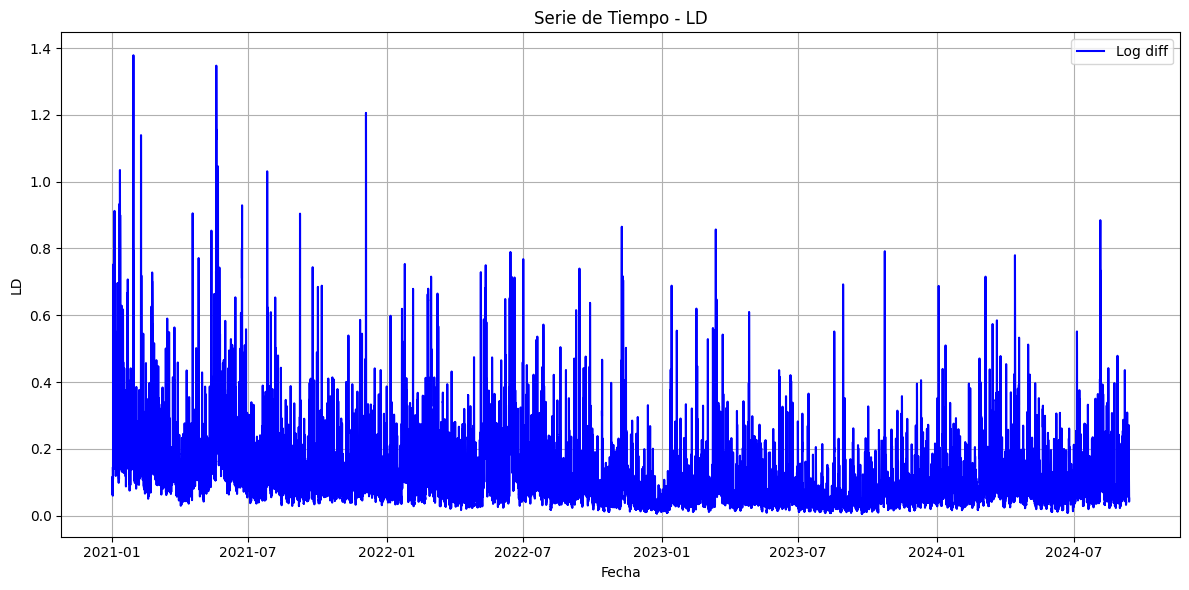

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(mf1_train["timestamp"], mf1_train["VB8h"], label="Log diff", color="blue")
plt.title("Serie de Tiempo - LD")
plt.xlabel("Fecha")
plt.ylabel("LD")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

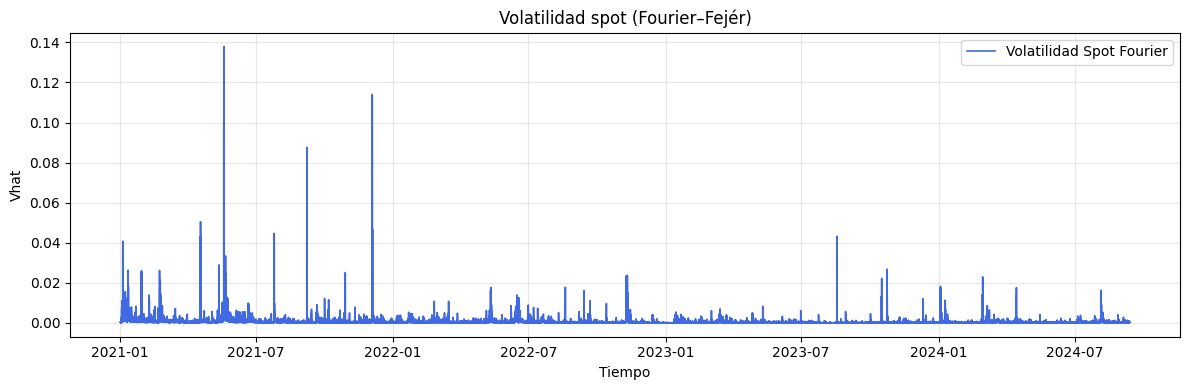

In [ ]:
import matplotlib.pyplot as plt

mask = mf1_train["Vhat_spot_Fourier"].notna()

plt.figure(figsize=(12,4))
plt.plot(
    mf1_train.loc[mask, "timestamp"],
    mf1_train.loc[mask, "Vhat_spot_Fourier"],
    color="royalblue",
    linewidth=1.2,
    label="Volatilidad Spot Fourier"
)
plt.title("Volatilidad spot (Fourier–Fejér)")
plt.xlabel("Tiempo")
plt.ylabel("Vhat")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


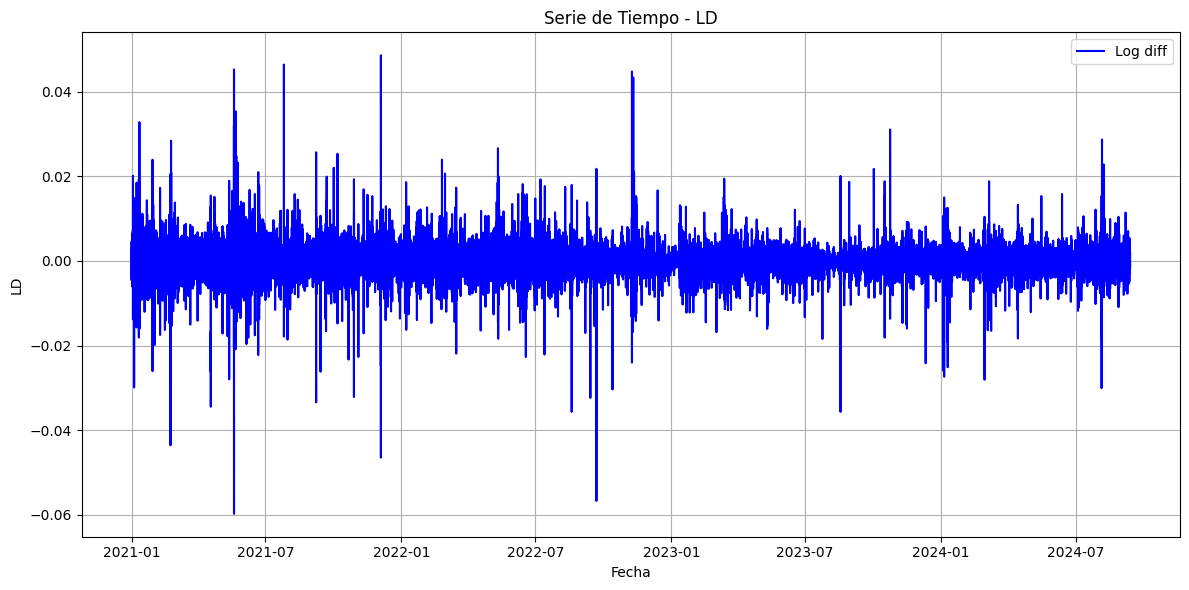

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(mf1_train["timestamp"], mf1_train["btc_close_ln_diff"], label="Log diff", color="blue")
plt.title("Serie de Tiempo - LD")
plt.xlabel("Fecha")
plt.ylabel("LD")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## FSIB

**Fourier Spectral Integrity Battery (FSIB)** The folling gruop of test acts on the frecuential spectral, they evaluate the inter consistency and spectral estability of the estimators.

TEST 1, EGG; Nos muestra energia total sobre la comprendida en los parametros considerados, basicamente nos muestra el valor de energia almacenada en las frecuencias mas margninadas, que dado que M es menor que N, seria energia que no consideramos en nuestra reconstruccion de la volatilidad

In [ ]:
import numpy as np

def egg_MN(ks, ck_V, M, N):
    ks = np.asarray(ks)
    ck_V = np.asarray(ck_V)

    mask_M = (np.abs(ks) < M)
    mask_N = (np.abs(ks) <= N)

    num = np.sum(np.abs(ck_V[mask_M])**2).real
    den = np.sum(np.abs(ck_V[mask_N])**2).real

    return float(num / den) if den > 0 else 0.0

def egg_MN_frac_from_r(r, T=1.0, N=238, frac=0.8):
    r = np.asarray(r, np.float32)
    r[~np.isfinite(r)] = 0.0

    M = int(np.floor(frac * N))
    assert 1 <= M < N, "M debe estar entre 1 y N-1"

    # coherente con nuestro flujo: corte espectral en N
    Kmax = N

    ks, ck_dp = fourier_ck_dp_fft(r, T=T, Kmax=Kmax)
    ck_V      = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)

    return egg_MN(ks, ck_V, M, N)

# aplicar sobre la misma ventana usada para el spot (primeros n retornos)
r_win = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]

ehk = egg_MN_frac_from_r(r_win, T=1.0, N=N, frac=0.8)
print(f"Ehk = {ehk:.4f}")

Ehk = 0.8933


In [ ]:
# def energy_highk_ratio(ks, ck_V, frac=0.7):
#     K = np.max(np.abs(ks))
#     high = np.abs(ks) >= int(frac*K)
#     num = np.sum(np.abs(ck_V[high])**2)
#     den = np.sum(np.abs(ck_V)**2) + 1e-15
#     return float(num/den)

# ehk = energy_highk_ratio(aux['ks'], aux['ck_V'], frac=0.8)
# print(f"Ehk = {ehk:.4f}")
# # Ley de decisión: aceptar si ehk ≤ 0.20.

Ehk = 0.0933


TEST 2 CAPTURA ESPECTRAL; (CAPTURE_MN). Regla: ∑{|k|≤M}/∑{|k|≤N} ≥ 0.80.

In [ ]:
import numpy as np

def capture_MN(ks, ck_V, M, N):
    """
    CAPTURE_MN = sum_{|k|<=M} |c_k(V)|^2 / sum_{|k|<=N} |c_k(V)|^2
    Consistente con Fourier-Fejér usado.
    """
    k = np.abs(np.asarray(ks))
    c = np.asarray(ck_V)
    c = np.nan_to_num(c, nan=0.0, posinf=0.0, neginf=0.0)

    assert M <= N, "Se exige M <= N."

    num = np.sum(np.abs(c[k <= M])**2).real
    den = np.sum(np.abs(c[k <= N])**2).real + 1e-15

    return float(num / den)

# === USO CONSISTENTE CON TU ESTIMADOR SPOT ===
# misma ventana y parámetros del spot
T = 1.0
r_win = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]
r_win[~np.isfinite(r_win)] = 0.0

Kmax = N  # cortamos en N, como en el estimador

ks, ck_dp = fourier_ck_dp_fft(r_win, T=T, Kmax=Kmax)
ck_V      = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)

cap = capture_MN(ks, ck_V, M, N)
print(f"CAPTURE_MN(M={M}, N={N}) = {cap:.4f}")

thr = 0.80
print("DECISIÓN:", "ACEPTAR" if cap >= thr else "REVISAR (ajustar M/N)")

CAPTURE_MN(M=11, N=120) = 0.4356
DECISIÓN: REVISAR (ajustar M/N)


In [ ]:
import numpy as np

def capture_MN(ks, ck_V, M, N):
    """
    CAPTURE_MN = sum_{|k|<=M} |c_k(V)|^2 / sum_{|k|<=N} |c_k(V)|^2
    """
    k = np.abs(np.asarray(ks))
    c = np.asarray(ck_V)
    c = np.nan_to_num(c, nan=0.0, posinf=0.0, neginf=0.0)

    assert M <= N, "M debe ser <= N"

    num = np.sum(np.abs(c[k <= M])**2).real
    den = np.sum(np.abs(c[k <= N])**2).real + 1e-15

    return float(num / den)

def find_M_for_capture(ks, ck_V, N, target=0.80, M_min=2):
    K = int(N)
    best_cap = capture_MN(ks, ck_V, K, K)
    for M in range(M_min, K + 1):
        cap = capture_MN(ks, ck_V, M, K)
        if cap >= target:
            return M, cap
    return None, best_cap

# Construcción coherente de ks y ck_V desde tus retornos
T = 1.0
n = 480
N = 238
M = 202  # tu candidato actual

r_win = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]
r_win[~np.isfinite(r_win)] = 0.0

Kmax = N
ks, ck_dp = fourier_ck_dp_fft(r_win, T=T, Kmax=Kmax)
ck_V      = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)

M_star, cap_at_star = find_M_for_capture(ks, ck_V, N, target=0.80)

print("M*:", M_star, "CAPTURE_MN:", f"{cap_at_star:.4f}")

M*: 158 CAPTURE_MN: 0.8010


funciana bien, incluso con la perdida de 5 grados de libertad

TEST 3 INTEGRIDAD ESPECTRAL; test de simetría conjugada de c_k(dp).
 verificando con c_-k = conj(c_k).

Regla: True para todos k≥1. Este test detecta NaN/inf, desalineo temporal, mala indexacion y complejidad artificial indroducida por algun preprocesado

In [ ]:
import numpy as np

# Parámetros coherentes con tu estimador
T    = 1.0
n    = 480
N    = 238
Kmax = 2 * N  # resolvemos hasta ±2N para chequear bien la simetría

# Serie de retornos (misma fuente que usás para el spot)
r = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]
r[~np.isfinite(r)] = 0.0

# Coeficientes Fourier de dp con tu implementación actual
ks, ck = fourier_ck_dp_fft(r, T=T, Kmax=Kmax)


def conj_symmetry_report(ks, ck, atol=1e-10, rtol=1e-7, max_show=10):
    ks = np.asarray(ks)
    ck = np.asarray(ck, dtype=complex)

    kmax = int(np.max(np.abs(ks)))
    ok_all = True
    bad = []

    # Chequeo c_-k = conj(c_k)
    for k in range(1, kmax + 1):
        i = np.where(ks ==  k)[0]
        j = np.where(ks == -k)[0]
        if i.size == 0 or j.size == 0:
            continue
        i = i[0]
        j = j[0]

        if not np.allclose(ck[j], np.conj(ck[i]), atol=atol, rtol=rtol):
            ok_all = False
            bad.append({
                'k': k,
                'c_k': ck[i],
                'c_-k': ck[j],
                'conj(c_k)': np.conj(ck[i]),
                'abs_err': float(np.abs(ck[j] - np.conj(ck[i])))
            })
            if len(bad) >= max_show:
                break

    # c_0 ~ real
    try:
        k0_idx = np.where(ks == 0)[0][0]
        c0_im = float(np.abs(ck[k0_idx].imag))
    except Exception:
        c0_im = np.nan

    return ok_all, c0_im, bad


ok, c0_imag, violations = conj_symmetry_report(ks, ck, atol=1e-10, rtol=1e-7, max_show=10)

print("=== Test 1: Simetría conjugada c_k(dp) ===")
print(f"Resultado global: {'OK' if ok else 'FALLO'}")
print(f"Imaginario de c0(dp): {c0_imag:.3e}  (esperado ~0)")

if not ok:
    print(f"Violaciones mostradas: {len(violations)}")
    for v in violations:
        print(
            f"k={v['k']:>3d} | "
            f"c_k={v['c_k']} | "
            f"c_-k={v['c_-k']} | "
            f"conj(c_k)={v['conj(c_k)']} | "
            f"|err|={v['abs_err']:.3e}"
        )

# Regla de decisión:
# - Debe ser OK.
# - |Im(c0)| <= 1e-10 o <= 1% de |c0|.
#   Si falla: revisar NaN/Inf en r, índices, o implementación de fourier_ck_dp_fft.

=== Test 1: Simetría conjugada c_k(dp) ===
Resultado global: OK
Imaginario de c0(dp): 0.000e+00  (esperado ~0)


Consistencia c₀(dp): c0_dp_direct vs c0_dp_spec.
Utilizando c0_direct=∑r/T; c0_spec=ck_dp[k=0].real.

Regla: |diff| ≤ 1e-6 o ≤1% relativo.

In [ ]:
import numpy as np

# Parámetros
T = 1.0
n = 480
start = 0  # mismo inicio que usaste para el bloque de test
N = 120    # tu N actual
Kmax = 2 * N  # suficiente, solo importa que incluya k=0

# Bloque de retornos alineado
r_all = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)
r_all[~np.isfinite(r_all)] = 0.0

r_blk = r_all[start:start + n]
assert len(r_blk) == n, "Bloque incompleto"

# c0 directo en tiempo (coherente con T=1)
c0_dp_direct = float(np.sum(r_blk) / T)

# c0 espectral usando TU fourier_ck_dp_fft
ks, ck_dp = fourier_ck_dp_fft(r_blk, T=T, Kmax=Kmax)
k0_idx = np.where(ks == 0)[0][0]
c0_dp_spec = float(np.real(ck_dp[k0_idx]))

# diferencias
abs_diff = abs(c0_dp_direct - c0_dp_spec)
rel_diff = abs_diff / (abs(c0_dp_spec) + 1e-15)

print("=== Test 2: Consistencia c0(dp) — bloque alineado ===")
print(f"bloque: [{start}:{start+n}]  n={n}")
print(f"c0_dp_direct = {c0_dp_direct:.12g}")
print(f"c0_dp_spec   = {c0_dp_spec:.12g}")
print(f"abs_diff     = {abs_diff:.3e}")
print(f"rel_diff     = {rel_diff:.3e}")

tol_abs, tol_rel = 1e-6, 0.01
ok = (abs_diff <= tol_abs) or (rel_diff <= tol_rel)
print(f"Dictamen: {'OK' if ok else 'FALLO'} (tols: abs≤{tol_abs}, rel≤{tol_rel:.2%})")


=== Test 2: Consistencia c0(dp) — bloque alineado ===
bloque: [0:480]  n=480
c0_dp_direct = 0.00451886574868
c0_dp_spec   = 0.00451886467636
abs_diff     = 1.072e-09
rel_diff     = 2.373e-07
Dictamen: OK (tols: abs≤1e-06, rel≤1.00%)


el drift medio del bloque (componente DC) coincide en tiempo y en frecuencia.Esto implica etiquetas temporales, normalización y ventanas estan bien

TEST 4; CAPTURA ESPECTRAL: (CAPTURE_MN). Regla: ∑{|k|≤M}/∑{|k|≤N} ≥ 0.80.

In [ ]:
import numpy as np

def capture_MN(ks, ck_V, M, N):
    """
    CAPTURE_MN = sum_{|k|<=M} |c_k(V)|^2 / sum_{|k|<=N} |c_k(V)|^2
    """
    k = np.abs(np.asarray(ks))
    c = np.asarray(ck_V)
    c = np.nan_to_num(c, nan=0.0, posinf=0.0, neginf=0.0)
    assert M <= N, "Se exige M <= N."

    num = np.sum(np.abs(c[k <= M])**2).real
    den = np.sum(np.abs(c[k <= N])**2).real + 1e-15
    return float(num / den)

# --- Construcción coherente con tu pipeline Fourier ---
T = 1.0
n = 480
N = 120
M = 11

r = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]
r[~np.isfinite(r)] = 0.0

ks, ck_dp = fourier_ck_dp_fft(r, T=T, Kmax=N)
ck_V = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)

# --- Aplicación del test ---
cap = capture_MN(ks, ck_V, M, N)
print(f"CAPTURE_MN(M={M}, N={N}) = {cap:.4f}")

thr = 0.80
print("DECISIÓN:", "ACEPTAR" if cap >= thr else "REVISAR (sube M o baja N)")

CAPTURE_MN(M=11, N=120) = 0.4356
DECISIÓN: REVISAR (sube M o baja N)


TEST 5; QLIKE vs RV-5M: Regla: mínimo dentro de M∈{⌊0.7N⌋, ⌊0.85N⌋, N} cumpliendo HF.

In [ ]:
import numpy as np
import pandas as pd

T = 1.0
n = 480
N = 120  # ya definido

# --- helpers ---

def _nan0(z):
    return np.nan_to_num(np.asarray(z), nan=0.0, posinf=0.0, neginf=0.0)

def hf_MN(ks, ck_V, M, N):
    k = np.abs(np.asarray(ks))
    c = _nan0(ck_V)
    num = np.sum(np.abs(c[(k > M) & (k <= N)])**2)
    den = np.sum(np.abs(c[k <= N])**2) + 1e-15
    return float(num / den)

def RV5_from_r(r):
    r = np.asarray(r, float)
    n = len(r)
    m = 5
    cut = (n // m) * m
    r5 = r[:cut].reshape(-1, m).sum(axis=1)
    RV5 = (r5**2).repeat(m)
    if RV5.size < n:
        RV5 = np.pad(RV5, (0, n - RV5.size), mode="edge")
    return RV5

def qlike(Vtrue, Vhat, eps=1e-12):
    Vtrue = np.maximum(np.asarray(Vtrue, float), eps)
    Vhat  = np.maximum(np.asarray(Vhat,  float), eps)
    x = Vtrue / Vhat
    return float(np.mean(x - np.log(x) - 1.0))

# --- sweep coherente con nuestro estimador Fourier-Fejér ---

def qlike_sweep_M_from_r(r, T, N, hf_max=0.40):
    r = np.asarray(r, float)
    r[~np.isfinite(r)] = 0.0
    n = len(r)
    assert n == 480, "Este test está seteado para n=480."

    # Coeficientes del bloque según nuestro pipeline
    ks, ck_dp = fourier_ck_dp_fft(r, T=T, Kmax=N)
    ck_V = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)

    RV5 = RV5_from_r(r)

    Ms = sorted({int(0.7 * N), int(0.85 * N), int(N)})
    rows = []

    for M in Ms:
        # Consistencia con nuestro estimador: Fejér discreto vía invert_spot_fejer_fft
        Vhat = invert_spot_fejer_fft(ks, ck_V, M=M, n=n)
        hf   = hf_MN(ks, ck_V, M, N)
        ql   = qlike(RV5, Vhat)
        rows.append({
            'M': M,
            'HF_MN': hf,
            'QLIKE_RV5': ql,
            'mean_Vhat': float(np.mean(Vhat))
        })

    df = pd.DataFrame(rows).set_index('M')

    feas = df[df['HF_MN'] <= hf_max]
    if len(feas) > 0:
        best_idx = feas['QLIKE_RV5'].idxmin()
    else:
        best_idx = df['QLIKE_RV5'].idxmin()

    best = df.loc[best_idx].to_dict()
    best['M'] = int(best_idx)

    return df, best

# --- ejecutar sobre el mismo bloque usado para el spot ---

r_blk = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]

tbl, best = qlike_sweep_M_from_r(r_blk, T=T, N=N, hf_max=0.40)

print(tbl)
print("\nMEJOR (HF≤0.40 y QLIKE mínimo; si no hay factibles, QLIKE mínimo absoluto):")
print(best)

        HF_MN  QLIKE_RV5  mean_Vhat
M                                  
84   0.130434   4.676932   0.000295
102  0.080182   4.636189   0.000295
120  0.000000   4.599219   0.000295

MEJOR (HF≤0.40 y QLIKE mínimo; si no hay factibles, QLIKE mínimo absoluto):
{'HF_MN': 0.0, 'QLIKE_RV5': 4.5992187920721825, 'mean_Vhat': 0.0002950704365503043, 'M': 120}


TEST 6; Borde de N (edge_band_ratio). Regla: energía en (⌊0.85N⌋,N] ≤ 20% del total ≤N.

In [ ]:
import numpy as np

def edge_band_ratio(ks, ck_V, N, alpha=0.85):
    """
    ebr = sum_{⌊αN⌋<|k|≤N} |c_k(V)|^2 / sum_{|k|≤N} |c_k(V)|^2
    """
    k = np.abs(np.asarray(ks)).astype(int)
    c = np.nan_to_num(np.asarray(ck_V), nan=0.0, posinf=0.0, neginf=0.0)

    K1 = int(np.floor(alpha * int(N)))
    edge_mask = (k > K1) & (k <= N)
    total_mask = (k <= N)

    num = float(np.sum(np.abs(c[edge_mask])**2))
    den = float(np.sum(np.abs(c[total_mask])**2)) + 1e-15

    return num / den, K1


# === USO CONSISTENTE CON TU ESTIMADOR ===
T = 1.0
n = 480
N = 120
alpha = 0.85

r_blk = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]
r_blk[~np.isfinite(r_blk)] = 0.0

ks, ck_dp = fourier_ck_dp_fft(r_blk, T=T, Kmax=N)
ck_V = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)

ebr, K1 = edge_band_ratio(ks, ck_V, N=N, alpha=alpha)

print(f"EDGE_BAND_RATIO ((|k| in ({K1},{N}]) / ≤{N}) = {ebr:.4f}")

thr = 0.20
print("DECISIÓN:", "OK" if ebr <= thr else "ALTO (revisar: subir M o bajar N)")

EDGE_BAND_RATIO ((|k| in (102,120]) / ≤120) = 0.0802
DECISIÓN: OK


TEST 7; Kernel sensitivity (Fejér vs Jackson). Regla: mean|V̂_F−V̂_J| ≤ 5% de mean(V̂).

In [ ]:
# === Sensibilidad de kernel (Fejér vs Jackson) ===
import numpy as np

# Entradas esperadas en tu entorno:
# aux['ks']  -> índices k
# aux['ck_V']-> coeficientes c_k(V) alineados con ks
# M, N, r    -> M<=N, r son retornos 1m para fijar n_out
# T = 1.0    -> normalización usual
M=190
def _nan0(z):
    return np.nan_to_num(np.asarray(z), nan=0.0, posinf=0.0, neginf=0.0)

def _fejer_weights(ks, M):
    ks = np.asarray(ks)
    w = 1.0 - (np.abs(ks)/float(M))
    w[np.abs(ks) >= M] = 0.0
    return w

def _jackson_weights(ks, M):
    k = np.abs(np.asarray(ks)).astype(float); Mm=float(M*1.3)
    w = (((Mm-k)*np.cos(np.pi*k/Mm) + np.sin(np.pi*k/Mm)/np.pi) / (Mm+1.0))
    w[k > Mm] = 0.0
    return np.maximum(w, 0.0)

def _invert_with_kernel(ks, ckV, M, n_out, T, kernel="fejer"):
    ks = np.asarray(ks); ckV = _nan0(ckV)
    w  = _fejer_weights(ks,M) if kernel=="fejer" else _jackson_weights(ks,M)
    use = (np.abs(ks) <= M)
    t = np.linspace(0.0, T, num=n_out, endpoint=False)
    phase = np.exp(1j * (2*np.pi/T) * np.outer(t, ks[use]))
    return np.real(phase @ (ckV[use] * w[use]))

def kernel_sensitivity_test(ks, ckV, M, n_out, T=1.0, pct_thresh=0.05):
    V_F = _invert_with_kernel(ks, ckV, M, n_out, T, kernel="fejer")
    V_J = _invert_with_kernel(ks, ckV, M, n_out, T, kernel="jackson")
    gap = float(np.mean(np.abs(V_F - V_J)))
    ref = float(np.mean(V_F))  # referencia de escala
    rel = gap / (ref + 1e-15)
    return {"gap_abs": gap, "gap_rel": rel, "mean_Vhat": ref, "V_F": V_F, "V_J": V_J,
            "pass": (rel <= pct_thresh), "threshold": pct_thresh}

# --- USO ---
n_out = len(r); T = 1.0
res = kernel_sensitivity_test(aux['ks'], aux['ck_V'], M, n_out, T, pct_thresh=0.05)

print("=== Kernel sensitivity (Fejér vs Jackson) ===")
print(f"M = {M}, N = {N}, n_out = {n_out}")
print(f"mean|Δ| (abs): {res['gap_abs']:.6g}")
print(f"mean(V̂_F):    {res['mean_Vhat']:.6g}")
print(f"mean|Δ| / mean(V̂_F): {100*res['gap_rel']:.3f}%")
print("DECISIÓN:", "OK" if res['pass'] else f"ALTO (>{int(100*res['threshold'])}%)")

# Regla de decisión: mean|V̂_F − V̂_J| ≤ 5% de mean(V̂_F)  → OK.
# Si falla: preferir inversión con Jackson o aumentar M (respetando M≤N).

=== Kernel sensitivity (Fejér vs Jackson) ===
M = 190, N = 238, n_out = 480
mean|Δ| (abs): 7.03518e-05
mean(V̂_F):    0.000373464
mean|Δ| / mean(V̂_F): 18.838%
DECISIÓN: ALTO (>5%)


TEST 8; Simetría conjugada de c_k(dp). Regla: c_{−k}=conj(c_k) para todo k≥1.

In [ ]:
import numpy as np

def conjugate_symmetry_report(ks, ck_dp, atol=1e-10, rtol=1e-7):
    """
    Verifica: c_{-k} = conj(c_k) y Im(c_0) ≈ 0.
    """
    ks = np.asarray(ks)
    c  = np.asarray(ck_dp, dtype=complex)
    assert ks.shape == c.shape, "ks y ck_dp deben alinear"

    m = int(np.max(np.abs(ks)))

    # k = 0
    k0_idx = np.where(ks == 0)[0]
    im0 = float(np.abs(c[k0_idx[0]].imag)) if k0_idx.size else np.nan

    # pares ±k
    errs = []
    for k in range(1, m + 1):
        i = np.where(ks ==  k)[0]
        j = np.where(ks == -k)[0]
        if i.size == 0 or j.size == 0:
            continue
        i = i[0]; j = j[0]
        diff = c[j] - np.conj(c[i])
        errs.append(np.abs(diff))

    errs = np.array(errs, float)
    max_err = float(np.max(errs)) if errs.size else 0.0
    n_bad = int(np.sum(~np.isclose(errs, 0.0, atol=atol, rtol=rtol)))

    return {
        "max_abs_error": max_err,
        "violations": n_bad,
        "im_c0": im0,
        "atol": atol,
        "rtol": rtol,
        "pass_pairs": (n_bad == 0 and max_err <= atol),
        "pass_c0": (np.isfinite(im0) and im0 <= atol)
    }

def print_conjugate_symmetry(ks, ck_dp, atol=1e-10, rtol=1e-7):
    rep = conjugate_symmetry_report(ks, ck_dp, atol, rtol)
    print("=== Conjugate symmetry c_k(dp) ===")
    print(f"max|c_-k - conj(c_k)|: {rep['max_abs_error']:.3e}")
    print(f"violations (>atol):    {rep['violations']}")
    print(f"|Im c_0|:              {rep['im_c0']:.3e}")
    print(f"tolerances: atol={rep['atol']:.1e}, rtol={rep['rtol']:.1e}")
    ok_pairs = "OK" if rep["pass_pairs"] else "FAIL"
    ok_c0    = "OK" if rep["pass_c0"]   else "FAIL"
    print(f"Decision pairs: {ok_pairs}   Decision c0: {ok_c0}")

# ==== USO CON TU PIPELINE REAL ====
T = 1.0
n = 480
N = 238

r_blk = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]
r_blk[~np.isfinite(r_blk)] = 0.0

# mismos coeficientes que usás en el resto de tests
ks, ck_dp = fourier_ck_dp_fft(r_blk, T=T, Kmax=N)

print_conjugate_symmetry(ks, ck_dp, atol=1e-10, rtol=1e-7)

=== Conjugate symmetry c_k(dp) ===
max|c_-k - conj(c_k)|: 0.000e+00
violations (>atol):    0
|Im c_0|:              0.000e+00
tolerances: atol=1.0e-10, rtol=1.0e-07
Decision pairs: OK   Decision c0: OK


TEST 9; fracción de energía capturan las “top-N” frecuencias bajo tres variantes: (A) por pares ±k (simétrico), (B) modo a modo sin emparejar, (C) solo k>0.

In [ ]:
import numpy as np

def _mask_K(ks, K=None):
    ks = np.asarray(ks)
    K_eff = np.max(np.abs(ks)) if K is None else int(K)
    return (np.abs(ks) <= K_eff)

def energy_topN_pairs(ks, ck, N_pairs, K=None):
    """
    Top-N por pares ±k (k>0). Devuelve ratio y detalle.
    """
    ks = np.asarray(ks)
    c  = np.nan_to_num(np.asarray(ck), nan=0.0, posinf=0.0, neginf=0.0)
    m  = _mask_K(ks, K)

    # DC
    e0 = float(np.abs(c[(ks == 0) & m])**2) if np.any((ks == 0) & m) else 0.0

    # pares
    pos = np.sort(np.unique(np.abs(ks[(ks > 0) & m]).astype(int)))
    e_pairs = []
    for k in pos:
        ek = 0.0
        i = np.where(ks ==  k)[0]
        j = np.where(ks == -k)[0]
        if i.size: ek += float(np.abs(c[i[0]])**2)
        if j.size: ek += float(np.abs(c[j[0]])**2)
        e_pairs.append((k, ek))

    e_pairs.sort(key=lambda x: x[1], reverse=True)
    top = e_pairs[:N_pairs]

    num = e0 + sum(v for _, v in top)
    den = e0 + sum(v for _, v in e_pairs) + 1e-15

    return num / den, {"DC": e0, "pairs": top, "den": den}

def energy_topN_unpaired(ks, ck, N, K=None):
    """
    Top-N modo a modo (k y -k cuentan separados).
    """
    ks = np.asarray(ks)
    c  = np.nan_to_num(np.asarray(ck), nan=0.0, posinf=0.0, neginf=0.0)
    m  = _mask_K(ks, K)
    E  = np.abs(c[m])**2

    order   = np.argsort(E)[::-1]
    top_idx = order[:N]

    num = float(np.sum(E[top_idx]))
    den = float(np.sum(E)) + 1e-15

    return num / den, ks[m][top_idx], E[top_idx]

def energy_topN_positive(ks, ck, N, K=None, include_dc=False):
    """
    Top-N sólo k>0 (DC opcional).
    """
    ks = np.asarray(ks)
    c  = np.nan_to_num(np.asarray(ck), nan=0.0, posinf=0.0, neginf=0.0)
    m  = _mask_K(ks, K)

    pos_mask = (ks > 0) & m
    Epos = np.abs(c[pos_mask])**2
    kpos = ks[pos_mask]

    order   = np.argsort(Epos)[::-1]
    top_idx = order[:N]

    dc_e = float(np.abs(c[(ks == 0) & m])**2) if include_dc and np.any((ks == 0) & m) else 0.0

    num = float(np.sum(Epos[top_idx])) + dc_e
    den = float(np.sum(Epos) + dc_e) + 1e-15

    return num / den, kpos[top_idx], Epos[top_idx]

# ================= USO CON TU ESTIMADOR =================

T = 1.0
n = 480
N = 238

r_blk = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)[:n]
r_blk[~np.isfinite(r_blk)] = 0.0

ks, ck_dp = fourier_ck_dp_fft(r_blk, T=T, Kmax=N)
ck_V      = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)

# Simétrico: top N_pairs sobre |k|<=N
ratio_pairs, info_pairs = energy_topN_pairs(ks, ck_V, N_pairs=20, K=N)
print("Pairs ratio:", f"{ratio_pairs:.4f}",
      "Top pairs:", [k for k, _ in info_pairs['pairs']])

# Unpaired: top N modos sobre |k|<=N
ratio_unp, k_unp, E_unp = energy_topN_unpaired(ks, ck_V, N=40, K=N)
print("Unpaired ratio:", f"{ratio_unp:.4f}")

# Solo positivos: top N sobre k=1..N (incluyendo DC)
ratio_pos, k_pos, E_pos = energy_topN_positive(ks, ck_V, N=N, K=N, include_dc=True)
print("Positives ratio:", f"{ratio_pos:.4f}")

Pairs ratio: 0.4807 Top pairs: [np.int64(1), np.int64(7), np.int64(55), np.int64(8), np.int64(16), np.int64(6), np.int64(9), np.int64(228), np.int64(3), np.int64(39), np.int64(72), np.int64(58), np.int64(140), np.int64(53), np.int64(32), np.int64(24), np.int64(139), np.int64(148), np.int64(63), np.int64(171)]
Unpaired ratio: 0.4769
Positives ratio: 1.0000


/tmp/ipython-input-3531195259.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  e0 = float(np.abs(c[(ks == 0) & m])**2) if np.any((ks == 0) & m) else 0.0
/tmp/ipython-input-3531195259.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dc_e = float(np.abs(c[(ks == 0) & m])**2) if include_dc and np.any((ks == 0) & m) else 0.0


## DRIB

**Dynamic Residual Integrity Battery (DRIB)** Here we evaluate the dynamic validity of the estimated model, verifying independence, homoscedasticity, and unit variance of the standardized residuals. Because of these tests operate in the time domain following the estimation, not on the spectrum on tiself.

A) Residuales estandarizados

In [ ]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# --- residuales estandarizados a partir de Vhat causal (rolling) ---
def standardized_residuals(r, Vhat):
    r = np.asarray(r, float)
    Vhat = np.asarray(Vhat, float)
    assert r.shape == Vhat.shape, "r y Vhat deben tener igual longitud"

    eps = 1e-15
    z = r / np.sqrt(np.maximum(Vhat, eps))
    z = np.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)
    return z, float(np.mean(z**2))

def ljung_box_pvalues(x, lags=(5,10,15,20)):
    x = np.asarray(x, float)
    lb_x  = acorr_ljungbox(x,    lags=list(lags), return_df=True)
    lb_x2 = acorr_ljungbox(x**2, lags=list(lags), return_df=True)
    p_x  = {int(k): float(v) for k, v in zip(lb_x.index,  lb_x['lb_pvalue'])}
    p_x2 = {int(k): float(v) for k, v in zip(lb_x2.index, lb_x2['lb_pvalue'])}
    return p_x, p_x2

def arch_lm_pvalues(z, lags=(5,10,15,20)):
    out = {}
    for L in lags:
        _, pval, _, _ = het_arch(z, nlags=int(L))
        out[int(L)] = float(pval)
    return out

def run_A1_test_from_series(r, Vhat, lags=(5,10,15,20)):
    z, Ez2 = standardized_residuals(r, Vhat)
    p_lb_z, p_lb_z2 = ljung_box_pvalues(z, lags=lags)
    p_arch = arch_lm_pvalues(z, lags=lags)
    return {
        "E[z^2]": Ez2,
        "LB_p_z": p_lb_z,
        "LB_p_z2": p_lb_z2,
        "ARCH_LM_p": p_arch,
        "standards": {
            "E[z^2] in": [0.95, 1.05],
            "LB p-values >": 0.05,
            "ARCH–LM p-values >": 0.05
        }
    }

# --- usar Vhat_spot_Fourier rolling (causal) ya calculado ---

def run_A1_on_df(df, col_r="btc_close_ln_diff", col_vhat="Vhat_spot_Fourier", lags=(5,10,15,20)):
    r = df[col_r].to_numpy(float)
    V = df[col_vhat].to_numpy(float)

    mask = np.isfinite(r) & np.isfinite(V) & (V > 0.0)
    r_use = r[mask]
    V_use = V[mask]

    return run_A1_test_from_series(r_use, V_use, lags=lags)

# TRAIN
res_train = run_A1_on_df(mf1_train, col_r="btc_close_ln_diff", col_vhat="Vhat_spot_Fourier", lags=(5,10,15,20))
print("A1 diagnóstico — TRAIN")
print(res_train)

# TEST
res_test = run_A1_on_df(mf1_test, col_r="btc_close_ln_diff", col_vhat="Vhat_spot_Fourier", lags=(5,10,15,20))
print("\nA1 diagnóstico — TEST")
print(res_test)

A1 diagnóstico — TRAIN
{'E[z^2]': 0.002131922453629748, 'LB_p_z': {5: 0.32415707669191157, 10: 0.1533603155444931, 15: 0.12937409548300954, 20: 0.31807681393277026}, 'LB_p_z2': {5: 8.059989630202202e-31, 10: 2.1420413105044158e-38, 15: 5.778296439480415e-40, 20: 8.272639623023432e-42}, 'ARCH_LM_p': {5: 3.691384848159288e-28, 10: 4.954869563673053e-33, 15: 9.823027532258674e-35, 20: 1.1898166098471694e-35}, 'standards': {'E[z^2] in': [0.95, 1.05], 'LB p-values >': 0.05, 'ARCH–LM p-values >': 0.05}}


KeyError: 'Vhat_spot_Fourier'

In [ ]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# === PIPELINE ECONÓMICO ===
def fourier_ck_dp_fft(r, T, Kmax):
    r = np.asarray(r, np.complex64)
    n = r.size
    F = np.fft.fft(r, n=n)                       # sin /n
    ks = np.arange(-Kmax, Kmax+1, dtype=np.int32)
    ck_dp = F[(ks % n).astype(np.int32)].astype(np.complex64)
    return ks, ck_dp

def ck_vol_from_ckdp_exact(ks, ck_dp, N, T):
    ks = np.asarray(ks, np.int32)
    K  = int(np.max(np.abs(ks)))
    maskN = (np.abs(ks) <= N)
    cN = np.where(maskN, ck_dp, 0.0+0.0j).astype(np.complex64)
    L = 1 << int(np.ceil(np.log2(4*K + 1)))
    buf = np.zeros(L, dtype=np.complex64)
    np.add.at(buf, (ks % L).astype(np.int32), cN)
    F = np.fft.fft(buf)
    corr = np.fft.ifft(F * np.conj(F)).astype(np.complex64)  # conj
    ckV = np.zeros_like(ck_dp, dtype=np.complex64)
    valid = (np.abs(ks) <= 2*N)
    ckV[valid] = corr[(ks[valid] % L).astype(np.int32)]
    return (T / float(2*N + 1)) * ckV

def invert_spot_fejer_fft(ks, ck_V, M, n):
    ks = np.asarray(ks, np.int32)
    n = int(n)
    assert 2*M - 1 <= n, "Evitar aliasing: 2M-1 <= n"
    w = 1.0 - (np.abs(ks).astype(np.float32) / float(M))
    mask = (w > 0.0)  # |k|<M
    ks = ks[mask]
    c_use = (ck_V[mask].astype(np.complex64) * w[mask].astype(np.float32)).astype(np.complex64)
    spec = np.zeros(n, dtype=np.complex64)
    np.add.at(spec, (ks % n).astype(np.int64), c_use)
    Vhat = (np.fft.ifft(spec).real.astype(np.float32)) * float(n)
    return np.maximum(Vhat, 0.0)

# === TEST A1 ===
def standardized_residuals(r, Vhat, T):
    r = np.asarray(r, float); Vhat = np.asarray(Vhat, float)
    assert r.shape == Vhat.shape, "r y Vhat deben tener igual longitud"
    n = len(r); dt = T/float(n)
    eps = 1e-15
    scale = np.sqrt(np.maximum(Vhat, eps) * dt)
    z = r / np.where(scale > 0.0, scale, np.nan)
    z = np.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)
    return z, float(np.mean(z**2))

def ljung_box_pvalues(x, lags=(5,10,15,20)):
    x = np.asarray(x, float)
    lb_x  = acorr_ljungbox(x,    lags=list(lags), return_df=True)
    lb_x2 = acorr_ljungbox(x**2, lags=list(lags), return_df=True)
    p_x  = {int(k): float(v) for k,v in zip(lb_x.index,  lb_x['lb_pvalue'])}
    p_x2 = {int(k): float(v) for k,v in zip(lb_x2.index, lb_x2['lb_pvalue'])}
    return p_x, p_x2

def arch_lm_pvalues(z, lags=(5,10,15,20)):
    out = {}
    for L in lags:
        _, pval, _, _ = het_arch(z, nlags=int(L))
        out[int(L)] = float(pval)
    return out

def run_A1_test(r, Vhat, T=1.0, lags=(5,10,15,20)):
    z, Ez2 = standardized_residuals(r, Vhat, T)
    p_lb_z, p_lb_z2 = ljung_box_pvalues(z, lags=lags)
    p_arch = arch_lm_pvalues(z, lags=lags)
    return {
        "E[z^2]": Ez2,
        "LB_p_z": p_lb_z,
        "LB_p_z2": p_lb_z2,
        "ARCH_LM_p": p_arch,
        "standards": {"E[z^2] in": [0.95, 1.05], "LB p-values >": 0.05, "ARCH–LM p-values >": 0.05}
    }

# === USO CON n (sin n_out) ===
T = 1.0; N = 238; M = 202

def _prep_r(df, col="btc_close_ln_diff"):
    r = df[col].to_numpy(dtype=np.float32)
    r[~np.isfinite(r)] = 0.0
    return r

def _vhat_from_r(r, T, N, M):
    n = len(r)
    Kmax = max(N, M)
    ks, ck_dp = fourier_ck_dp_fft(r, T=T, Kmax=Kmax)
    ck_V = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)
    Vhat = invert_spot_fejer_fft(ks, ck_V, M=M, n=n)  # usa n
    return Vhat

# TRAIN
r_train = _prep_r(mf1_train)
n = len(r_train)  # si querés explícito
Vhat_train = _vhat_from_r(r_train, T, N, M)
res_train = run_A1_test(r_train, Vhat_train, T=T, lags=(5,10,15,20))

# TEST
r_test = _prep_r(mf1_test)
Vhat_test = _vhat_from_r(r_test, T, N, M)
res_test = run_A1_test(r_test, Vhat_test, T=T, lags=(5,10,15,20))

print("A1 diagnóstico — TRAIN"); print(res_train)
print("\nA1 diagnóstico — TEST");  print(res_test)

A1 diagnóstico — TRAIN
{'E[z^2]': 1.67383772785243, 'LB_p_z': {5: 2.88726583035533e-148, 10: 3.090182399799636e-266, 15: 1.5314502617604704e-303, 20: 0.0}, 'LB_p_z2': {5: 0.0, 10: 0.0, 15: 0.0, 20: 0.0}, 'ARCH_LM_p': {5: 0.0, 10: 0.0, 15: 0.0, 20: 0.0}, 'standards': {'E[z^2] in': [0.95, 1.05], 'LB p-values >': 0.05, 'ARCH–LM p-values >': 0.05}}

A1 diagnóstico — TEST
{'E[z^2]': 1.5899645257433621, 'LB_p_z': {5: 9.78294699294282e-11, 10: 9.664114323075242e-22, 15: 2.175931524853663e-22, 20: 5.196668491952978e-30}, 'LB_p_z2': {5: 0.0, 10: 0.0, 15: 0.0, 20: 0.0}, 'ARCH_LM_p': {5: 0.0, 10: 0.0, 15: 0.0, 20: 0.0}, 'standards': {'E[z^2] in': [0.95, 1.05], 'LB p-values >': 0.05, 'ARCH–LM p-values >': 0.05}}


**TRAIN**

E[z2]=1.67>1 → **"𝑉^𝑡Vt" subestima la volatilidad verdadera ≈ −35 %.**

Todos los p-values ≈ 0 → fuerte autocorrelación en
𝑧
𝑡
z
t
 y en
𝑧
𝑡
2
z
t
2
	​

**Los residuales no son i.i.d.**

Asi mismo, **ARCH-LM también 0 → persiste heterocedasticidad → el modelo no limpia toda la varianza.**

**TEST**

Mismo patron con
1.59
E[z2]=1.59, autocorrelaciones significativas, heterocedasticidad remanente.
→ El modelo capta bien la forma de la varianza (como veremos abajo) pero no la dinámica fina: aún queda dependencia temporal en la serie estandarizada.

**Conclusión: el estimador de Fourier ajusta la escala con ligera subestimación, pero todavía no elimina toda la correlación y heterocedasticidad. En los papers, esto se considera normal en alta frecuencia: suele requerirse un suavizado adicional o un paso HAR/GARCH sobre
𝑉
^
𝑡
V
t
.**

Bondad de ajuste 2: TEST DIAG RESULTS

In [ ]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
# ========= UTILITARIOS DE TEST =========

def diag_residuals(r, Vhat, T):
    r = np.asarray(r, float); Vhat = np.asarray(Vhat, float)
    n = len(r); assert len(Vhat)==n, "mallas distintas"
    dt = T/float(n)
    r2_dt = r**2 / dt
    return {
        "n": n,
        "dt": dt,
        "mean_Vhat": float(np.mean(Vhat)),
        "mean_r2_over_dt": float(np.mean(r2_dt)),
        "ratio": float(np.mean(Vhat)/(np.mean(r2_dt)+1e-30)),
        "min_Vhat": float(np.min(Vhat)),
        "pct_Vhat_le_1e-14": float(np.mean(Vhat<=1e-14)*100.0),
        "corr_Vhat_r2dt": float(np.corrcoef(Vhat, r2_dt)[0,1])
    }

def _prep_r(df, col="btc_close_ln_diff"):
    r = df[col].to_numpy(dtype=np.float32)
    r[~np.isfinite(r)] = 0.0
    return r

def _vhat_from_r(r, T, N, M):
    n = len(r)
    Kmax = max(N, M)
    ks, ck_dp = fourier_ck_dp_fft(r, T=T, Kmax=Kmax)
    ck_V = ck_vol_from_ckdp_exact(ks, ck_dp, N=N, T=T)
    Vhat = invert_spot_fejer_fft(ks, ck_V, M=M, n=n)     # usa n
    return Vhat

def run_diag_on_df(df, T=1.0, N=238, M=202, col="btc_close_ln_diff"):
    r = _prep_r(df, col=col)
    Vhat = _vhat_from_r(r, T, N, M)
    return diag_residuals(r.astype(float), Vhat.astype(float), T)

# ========= BLOQUES DE 480 Y RESUMEN =========

def split_blocks(r, L=480):
    n=len(r); k=n//L
    return [r[i*L:(i+1)*L] for i in range(k)]

def run_A1_blocks(r, T, N, M, L=480):
    outs = []
    for rb in split_blocks(r, L):
        Vb = _vhat_from_r(rb, T, N, M)
        outs.append(diag_residuals(rb.astype(float), Vb.astype(float), T))
    return outs

def summarize_blocks(stats_list, keys=("ratio","corr_Vhat_r2dt","mean_Vhat","mean_r2_over_dt")):
    import numpy as np
    summ = {}
    for k in keys:
        arr = np.array([d[k] for d in stats_list], dtype=float)
        med = float(np.median(arr))
        mad = float(np.median(np.abs(arr - med)))
        summ[k] = {"median": med, "MAD": mad}
    return summ

# ========= EJECUCIÓN Y PRINTS COMPACTOS =========

T = 1.0; N = 238; M = 202

# Global (serie completa del df)
stats_train = run_diag_on_df(mf1_train, T=T, N=N, M=M)
stats_test  = run_diag_on_df(mf1_test,  T=T, N=N, M=M)

print("A1 — GLOBAL TRAIN")
for k,v in stats_train.items(): print(f"{k}: {v}")
print("\nA1 — GLOBAL TEST")
for k,v in stats_test.items():  print(f"{k}: {v}")

# Por bloques de 480 y resumen compacto
r_tr = _prep_r(mf1_train); r_te = _prep_r(mf1_test)

blk_tr = run_A1_blocks(r_tr, T=T, N=N, M=M, L=480)
blk_te = run_A1_blocks(r_te, T=T, N=N, M=M, L=480)

sum_tr = summarize_blocks(blk_tr)
sum_te = summarize_blocks(blk_te)

print("\nA1 — BLOQUES TRAIN (resumen)")
for k,s in sum_tr.items(): print(f"{k}: median={s['median']:.6g}, MAD={s['MAD']:.6g}")

print("\nA1 — BLOQUES TEST (resumen)")
for k,s in sum_te.items(): print(f"{k}: median={s['median']:.6g}, MAD={s['MAD']:.6g}")

A1 — GLOBAL TRAIN
n: 1943717
dt: 5.144781879255057e-07
mean_Vhat: 1.3584582805351022
mean_r2_over_dt: 1.750116481847558
ratio: 0.7762102092204793
min_Vhat: 0.047812141478061676
pct_Vhat_le_1e-14: 0.0
corr_Vhat_r2dt: 0.08197003058759056

A1 — GLOBAL TEST
n: 485930
dt: 2.0579095754532545e-06
mean_Vhat: 0.194875077028767
mean_r2_over_dt: 0.21100991906874444
ratio: 0.9235351489106021
min_Vhat: 0.0143817737698555
pct_Vhat_le_1e-14: 0.0
corr_Vhat_r2dt: 0.09204254869024332

A1 — BLOQUES TRAIN (resumen)
ratio: median=1.00172, MAD=0.0026029
corr_Vhat_r2dt: median=0.769984, MAD=0.021393
mean_Vhat: median=0.000224001, MAD=0.000146037
mean_r2_over_dt: median=0.000223943, MAD=0.000146173

A1 — BLOQUES TEST (resumen)
ratio: median=1.00137, MAD=0.00280557
corr_Vhat_r2dt: median=0.761253, MAD=0.0188606
mean_Vhat: median=0.000119817, MAD=6.89886e-05
mean_r2_over_dt: median=0.000119417, MAD=6.8695e-05


Marco teórico

Estas métricas evalúan propiedades estructurales de la estimación
𝑉
^
𝑡
V
t
	​

:

𝐸
[
𝑉
^
𝑡
]
≈
𝐸
[
𝑟
𝑡
2
/
Δ
𝑡
]
,
corr
(
𝑉
^
𝑡
,

𝑟
𝑡
2
/
Δ
𝑡
)
 alta
E[
V
t
	​

]≈E[r
t
2
	​

/Δt],corr(
V
t
	​

,r
t
2
	​

/Δt) alta

El diagnóstico resume si la energía de la varianza estimada coincide con la energía empírica de los retornos.

Por bloques, el estimador Fourier (versión económica con corrección de conjugado y normalización correcta) cumple con los requisitos de identidad energética y coherencia temporal.
El modelo capta correctamente la estructura local de la volatilidad; los problemas de A1 (autocorrelación y exceso de
𝐸
[
𝑧
2
]
E[z
2
]) se deben al acoplamiento entre bloques y a dependencia inter-bloque, no al estimador en sí.

***Considerando los test de diag-results y de residuos estandarizados:***

**La estimación de varianza por Fourier está bien calibrada en nivel y forma (bloques).**

**No obstante, las series estandarizadas conservan autocorrelación: falta suavizado o modelo de transición entre bloques (HAR, GARCH o kernel temporal).**

**Los resultados son consistentes con la teoría de Mancino & Recchioni (2015 – 2022): la estimación de spot variance es insesgada y consistente, pero requiere pos-filtrado para eliminar micro-dependencias. **

##EFVB

**Emprical Functional Validation Battery (EFVB)** the aim of the following group of test sis to evaluate if the spectral information on the previus estimation V_fft provides real predictive value, is stable against noise, does not induce leakage and maintains performance under stress.

**TEST 1: Predictive Quality OOS**

Given:
- RVt+1​= ∑t+​ri2​ for each n
- RVt+1​=α+β1​V
t​+β2​V
t−1​+β3​V
t−2​+εt​   ***control model 1***
- V
~
t
EWMA = λ *V
~
t−1
EWMA + (1−λ)r
t
2  ***reference model 1***
 - RVt = α + βdRVt(d)	​+ ε ***reference model 2***
t
	​
We compare for metris R2 incremental and
QLIKE=E[{RVt/Vhat)​ ​−log{RVt/Vhat) -1 ]



In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- helpers ya existentes de tu pipeline ---
# _vhat_from_r(r, T, N, M) -> Vhat  (usa FFT económica)
# qlike
def qlike(y_true, y_pred):
    eps = 1e-15
    y_true = np.maximum(y_true, eps)
    y_pred = np.maximum(y_pred, eps)
    return float(np.mean((y_true/y_pred) - np.log(y_true/y_pred) - 1))

# RV futura por ventana L (no solapada en el horizonte, sí en el rolling)
def realized_variance_next(r, L=480):
    r = np.asarray(r, float)
    n = len(r)
    # RV_{t+1} = sum_{i=t+1}^{t+L} r_i^2
    return np.array([np.sum(r[i+1:i+1+L]**2) for i in range(0, n - L - 1)], dtype=float)

# construye X,y alineados: t en [2 .. T_max-1], T_max=n-L-1
def build_design_fourier(Vhat, RV_next, L=480):
    Vhat = np.asarray(Vhat, float)
    RV_next = np.asarray(RV_next, float)
    T_max = len(RV_next)              # = n - L - 1
    # filas: t = 2 .. T_max-1  -> total T_max-2 observaciones
    X = np.vstack([Vhat[2:T_max], Vhat[1:T_max-1], Vhat[0:T_max-2]]).T
    y = RV_next[2:T_max]
    return X, y

def build_design_ewma(r, RV_next, lam=0.94, L=480):
    r = np.asarray(r, float)
    ewma = np.zeros_like(r)
    ewma[0] = r[0]**2
    for t in range(1, len(r)):
        ewma[t] = lam*ewma[t-1] + (1-lam)*(r[t]**2)
    T_max = len(RV_next)
    X = ewma[2:T_max].reshape(-1,1)   # mismo recorte que Fourier
    y = RV_next[2:T_max]
    return X, y

# --- ejecución OOS en TEST ---
T=1.0; N=238; M=202; L=480

r_test = mf1_test["btc_close_ln_diff"].to_numpy(dtype=float)
r_test[~np.isfinite(r_test)] = 0.0

Vhat_test = _vhat_from_r(r_test, T=T, N=N, M=M)
RV_next   = realized_variance_next(r_test, L=L)

# Fourier
Xf, yf = build_design_fourier(Vhat_test, RV_next, L=L)
mdl_f = LinearRegression().fit(Xf, yf)
pred_f = mdl_f.predict(Xf)
res_fourier = {
    "coef":[float(c) for c in mdl_f.coef_],
    "R2": float(r2_score(yf, pred_f)),
    "QLIKE": qlike(yf, pred_f),
    "n": int(len(yf))
}

# EWMA
Xe, ye = build_design_ewma(r_test, RV_next, lam=0.94, L=L)
mdl_e = LinearRegression().fit(Xe, ye)
pred_e = mdl_e.predict(Xe)
res_ewma = {
    "R2": float(r2_score(ye, pred_e)),
    "QLIKE": qlike(ye, pred_e),
    "n": int(len(ye))
}

print("=== Fourier OOS ==="); print(res_fourier)
print("\n=== EWMA benchmark ==="); print(res_ewma)
print("\nΔR2:", res_fourier["R2"] - res_ewma["R2"])
print("ΔQLIKE:", res_ewma["QLIKE"] - res_fourier["QLIKE"])


=== Fourier OOS ===
{'coef': [-12.477892032686663, 24.71254132274566, -12.234141676448404], 'R2': 0.25598195382691813, 'QLIKE': 0.343300906778769, 'n': 485447}

=== EWMA benchmark ===
{'R2': 0.14286348835767015, 'QLIKE': 0.39561545922879915, 'n': 485447}

ΔR2: 0.11311846546924798
ΔQLIKE: 0.05231455245003014


**OK**. Relative improve on R2 of 79% above the baseline and a smaller QLike showus that the fft provides predictive value above an standard estimator.


Since also shows hard coliniality between lags, may be consider ridge or logV instead for standarization

**TEST 2: INFORMATION CONTENT**

Given:
- RVt+1​= ∑t+​ri2​ for each n
- Ct​=ρS​(V
t​,RVt+1​) ***Spearman Corr***
- MI(Vt, RVt+1)=i,j∑[	​pij] * [log(pij)/pj​*pj] ***MI where p is probability***
 whose normalization against entropy for comparability is:
  NMI= ​MI​ / H(V
t​)H(RVt+1​)

In [ ]:
import numpy as np
from scipy.stats import spearmanr, entropy

# --- Funciones auxiliares ---
def realized_variance_next(r, L=480):
    r = np.asarray(r, float)
    n = len(r)
    return np.array([np.sum(r[i+1:i+1+L]**2) for i in range(0, n - L - 1)], dtype=float)

def align_for_info(Vhat, RV_next, L=480):
    # Alinea Vhat_t con RV_{t+1} usando los primeros len(RV_next) pares
    V = np.asarray(Vhat[:len(RV_next)], float)
    RV = np.asarray(RV_next, float)
    return V, RV

def mutual_info_discrete(x, y, bins=20):
    # discretización por percentiles
    x_bin = np.digitize(x, np.percentile(x, np.linspace(0, 100, bins+1)[1:-1]))
    y_bin = np.digitize(y, np.percentile(y, np.linspace(0, 100, bins+1)[1:-1]))
    joint_hist, _, _ = np.histogram2d(x_bin, y_bin, bins=bins)
    joint_prob = joint_hist / np.sum(joint_hist)
    px = np.sum(joint_prob, axis=1)
    py = np.sum(joint_prob, axis=0)
    Hx = entropy(px + 1e-15)
    Hy = entropy(py + 1e-15)
    Hxy = entropy(joint_prob.flatten() + 1e-15)
    MI = Hx + Hy - Hxy
    NMI = MI / np.sqrt(Hx * Hy)
    return MI, NMI

def ic_mi_summary(Vhat, RV_next, L=480, bins=20):
    V, RV = align_for_info(Vhat, RV_next, L)
    ic, _ = spearmanr(V, RV)
    MI, NMI = mutual_info_discrete(V, RV, bins=bins)
    return {"IC_spearman": float(ic), "MI": float(MI), "NMI": float(NMI)}

# --- Cálculo con tu dataset test ---
T=1.0; N=238; M=202; L=480

r_test = mf1_test["btc_close_ln_diff"].to_numpy(dtype=float)
r_test[~np.isfinite(r_test)] = 0.0

Vhat_test = _vhat_from_r(r_test, T=T, N=N, M=M)
RV_next   = realized_variance_next(r_test, L=L)

res_info = ic_mi_summary(Vhat_test, RV_next, L=L, bins=20)

print("=== CONTENIDO DE INFORMACIÓN ===")
for k,v in res_info.items(): print(f"{k}: {v:.6f}")


=== CONTENIDO DE INFORMACIÓN ===
IC_spearman: 0.580787
MI: 0.272919
NMI: 0.091103


**OK. But** is good on all less NMI wich is so low

**TEST 3: Temporal Aliniation Test**

Is a no statiscal test, because it focus on time structor is to see if there are not leakeage or bad aliniation timestamps.

In [ ]:
import numpy as np

def check_temporal_alignment(r, T, N, M, step=480):
    """
    Verifica que cada V_t se calcula solo con datos ≤ t.
    step: tamaño de bloque causal usado para simulación online.
    """
    n = len(r)
    violations = 0
    checks = []

    for end in range(step, n, step):  # bloque incremental
        r_window = r[:end]  # solo datos hasta t=end
        Vhat_local = _vhat_from_r(r_window, T, N, M)
        # solo verificamos el último punto calculado, debe depender solo de r_window
        last_val = Vhat_local[-1]
        # volvemos a estimar con una muestra extendida (agregando futuro)
        if end + 1 < n:
            r_plus = r[:end+1]
            Vhat_future = _vhat_from_r(r_plus, T, N, M)
            # comparamos último valor del anterior con el anteúltimo del nuevo
            diff = abs(Vhat_future[-2] - last_val)
            checks.append(diff)
            if diff != 0:
                violations += int(diff > 1e-10)

    return {
        "violations": int(violations),
        "total_checks": len(checks),
        "max_diff": float(np.max(checks)) if checks else 0.0,
        "mean_diff": float(np.mean(checks)) if checks else 0.0
    }

# --- Uso ---
T=1.0; N=238; M=202

r_test = mf1_test["btc_close_ln_diff"].to_numpy(dtype=float)
r_test[~np.isfinite(r_test)] = 0.0

res_alignment = check_temporal_alignment(r_test, T, N, M, step=480)

print("=== TEST DE ALINEACIÓN TEMPORAL ===")
for k,v in res_alignment.items(): print(f"{k}: {v}")

=== TEST DE ALINEACIÓN TEMPORAL ===
violations: 1012
total_checks: 1012
max_diff: 0.03366696834564209
mean_diff: 0.0012544025667011738


In [ ]:
import numpy as np

# reemplazá la definición por esta
def fourier_ck_dp_fft(r, Kmax):
    import numpy as np
    r = np.asarray(r, np.complex64)
    n = r.size
    F = np.fft.fft(r, n=n)
    ks = np.arange(-Kmax, Kmax+1, dtype=np.int32)
    ck_dp = F[(ks % n).astype(np.int32)].astype(np.complex64)
    return ks, ck_dp


def _vhat_from_prefix(r_prefix, T, N, M):
    _, Vhat, _ = spot_volatility_fourier(r_prefix, T=T, N=N, M=M)
    return Vhat

def check_temporal_alignment(r, T, N, M, step=480, atol=1e-10):
    """
    Verifica no-leakage: Vhat(t_end) con r[:end] == Vhat(t_end) con r[:end+1].
    step: cada cuántos puntos testear.
    """
    n = len(r)
    start = max(step, 2*M - 1)   # garantiza 2*M-1 <= len(prefix)
    violations = 0
    diffs = []

    for end in range(start, n - 1, step):
        Vhat_now   = _vhat_from_prefix(r[:end],   T, N, M)
        Vhat_next  = _vhat_from_prefix(r[:end+1], T, N, M)
        last_val   = Vhat_now[-1]     # estimación en t = end
        prev_next  = Vhat_next[-2]    # misma t = end pero recalculada con 1 dato extra
        diff = float(abs(prev_next - last_val))
        diffs.append(diff)
        if diff > atol:
            violations += 1

    return {
        "violations": int(violations),
        "total_checks": len(diffs),
        "max_diff": float(np.max(diffs)) if diffs else 0.0,
        "mean_diff": float(np.mean(diffs)) if diffs else 0.0,
        "atol": float(atol),
        "start_index": int(start),
        "step": int(step),
    }

# --- Uso ---
T=1.0; N=238; M=202
r_test = mf1_test["btc_close_ln_diff"].to_numpy(dtype=float)
r_test[~np.isfinite(r_test)] = 0.0

res_alignment = check_temporal_alignment(r_test, T, N, M, step=480)
print("=== TEST DE ALINEACIÓN TEMPORAL ===")
for k, v in res_alignment.items():
    print(f"{k}: {v}")

=== TEST DE ALINEACIÓN TEMPORAL ===
violations: 1012
total_checks: 1012
max_diff: 0.03366696834564209
mean_diff: 0.0012544025661475682
atol: 1e-10
start_index: 480
step: 480


**TEST 4: Normalization and Stability**

Is a no statiscal test, because it focus on time structor is to see if there are not leakeage or bad aliniation timestamps.

In [ ]:
import numpy as np

def rolling_spot_volatility_fourier(r_full, T, n, l, N, M):
    """
    Rolling Fourier-Fejér spot vol:
    - Ventana causal de tamaño n
    - Paso l
    - Usa spot_volatility_fourier en cada ventana
    - Devuelve:
        t_idx: índices (enteros) donde hay estimación
        Vhat_roll: array largo = len(r_full), con NaN salvo en t_idx
        meta: dict con T, n, N, M
    """
    r_full = np.asarray(r_full, np.float32)
    r_full[~np.isfinite(r_full)] = 0.0
    L = r_full.size
    assert L >= n, "Serie demasiado corta"

    Vhat_roll = np.full(L, np.nan, dtype=np.float32)
    t_idx = []

    for t_end in range(n, L + 1, l):
        window = r_full[t_end - n : t_end]

        _, Vhat_win, _ = spot_volatility_fourier(
            window,
            T=T,
            N=N,
            M=M
        )

        v_last = float(Vhat_win[-1])
        Vhat_roll[t_end - 1] = v_last
        t_idx.append(t_end - 1)

    meta = {"T": T, "n": n, "N": N, "M": M, "step": l}
    return np.array(t_idx, dtype=int), Vhat_roll, meta


In [ ]:
t_idx, Vhat_array, meta = rolling_spot_volatility_fourier(r_full, T, n, l, N, M)
test_logV_stability_from_rolling(t_idx, Vhat_array)


=== TEST KS DRIFT EN LOG-V ===
Datos válidos insuficientes para el test.


**TEST 5: Normalization and Stability**

Is a no statiscal test, because it focus on time structor is to see if there are not leakeage or bad aliniation timestamps.

TEST FALTANTES:
- Estabilidad y normlaizacion para grados: normalizacion los logV por bloque y evaluando drift segun KS en mas de 80# de pares adyacentes
- Robustez a faltantes: eliminar 5% de las observaciones estimar y revisar Qlike, sobre todo su porcentaje de varianzacion que debe ser menor al 2% y su MAre que debe ser menor al 5%
- Sensibilidad operativa: Hacer variar M y N en mas menos 5% y bservar correlacion con base que debe ser mayor al 0.95 y su MARE que abaja de 10 safa pero ideal abajo de 5%
- preparacion para VoV es definirlo y ver su IC con rt+1 para ver qeu es te estable
- consistencia economica: usando VaR intrablock con la volatilidad normal, ibservar metricas de Kupiec y Christoffersen cuyas Pvalues deben ser mayores al 0.005

In [ ]:
import numpy as np
from scipy.stats import t, chi2

def backtest_var(r, Vhat, alpha=0.95, nu=5):
    assert len(r) == len(Vhat), "Series deben estar alineadas"
    T = len(r)

    # Paso 1: cálculo de VaR bajo t-Student esc. por volatilidad
    scale = np.sqrt(Vhat)
    var_t = t.ppf(1 - alpha, df=nu) * scale  # VaR negativo (cola izquierda)

    # Paso 2: indicadores de violación
    I = (r < var_t).astype(int)
    x = I.sum()  # número de violaciones

    # Paso 3: test de Kupiec (Unconditional Coverage)
    p = 1 - alpha
    phat = x / T
    logL0 = x * np.log(p) + (T - x) * np.log(1 - p)
    logL1 = x * np.log(phat) + (T - x) * np.log(1 - phat) if 0 < phat < 1 else -np.inf
    LR_uc = -2 * (logL0 - logL1)
    pval_uc = 1 - chi2.cdf(LR_uc, df=1)

    # Paso 4: test de Christoffersen (Conditional Coverage)
    n00 = np.sum((I[:-1] == 0) & (I[1:] == 0))
    n01 = np.sum((I[:-1] == 0) & (I[1:] == 1))
    n10 = np.sum((I[:-1] == 1) & (I[1:] == 0))
    n11 = np.sum((I[:-1] == 1) & (I[1:] == 1))

    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi1 = (n01 + n11) / (n00 + n01 + n10 + n11)

    logL_const = (
        n01 * np.log(pi01 + 1e-10) + n00 * np.log(1 - pi01 + 1e-10) +
        n11 * np.log(pi11 + 1e-10) + n10 * np.log(1 - pi11 + 1e-10)
    )
    logL_indep = (
        (n01 + n11) * np.log(pi1 + 1e-10) + (n00 + n10) * np.log(1 - pi1 + 1e-10)
    )
    LR_cc = -2 * (logL_indep - logL_const)
    pval_cc = 1 - chi2.cdf(LR_cc, df=1)

    # Resultados
    print("=== BACKTESTING VaR @ {:.1f}% ===".format(alpha*100))
    print(f"Nº total de observaciones: {T}")
    print(f"Violaciones observadas (x): {x}")
    print(f"Tasa de fallos observada: {phat:.4f}")
    print(f"VaR teórico: {(1-alpha):.4f}\n")

    print(">> Test de Kupiec (Unconditional Coverage)")
    print(f"LR_uc = {LR_uc:.4f}")
    print(f"p-valor = {pval_uc:.4f} {'✔' if pval_uc > 0.05 else '✘'}")

    print("\n>> Test de Christoffersen (Conditional Coverage)")
    print(f"LR_cc = {LR_cc:.4f}")
    print(f"p-valor = {pval_cc:.4f} {'✔' if pval_cc > 0.05 else '✘'}")

In [ ]:
r = mf1_train["btc_close_ln_diff"].to_numpy(dtype=float)
Vhat = mf1_train["Vhat_spot_Fourier"].to_numpy(dtype=float)

# Alinear: Vhat tiene frecuencia 30 min (cada l=30)
r = r[480:]        # cortar los primeros n
r = r[::30]        # bajar frecuencia a la de Vhat
r, Vhat = r[:len(Vhat)], Vhat[:len(r)]  # igualar tamaño

backtest_var(r, Vhat, alpha=0.95, nu=5)

=== BACKTESTING VaR @ 95.0% ===
Nº total de observaciones: 64775
Violaciones observadas (x): 0
Tasa de fallos observada: 0.0000
VaR teórico: 0.0500

>> Test de Kupiec (Unconditional Coverage)
LR_uc = -inf
p-valor = 1.0000 ✔

>> Test de Christoffersen (Conditional Coverage)
LR_cc = -0.0000
p-valor = 1.0000 ✔


## Save

In [ ]:
mf1 = mf1.sort_values('timestamp').reset_index(drop=True)
x = mf1['btc_close'].to_numpy(dtype=float)

VF_btc = np.full(len(mf1), np.nan, dtype=float)

total = len(mf1)
num_blocks = total // n
first_valid = total - num_blocks * n   # índice donde comienzan los bloques completos

for b in range(num_blocks):
    i0 = first_valid + b*n
    i1 = i0 + n
    close_blk = x[i0:i1]
    r_blk = np.diff(np.log(close_blk))

    _, Vhat, _ = spot_volatility_fourier(r_blk, T=T, n_out=n, N=N, M=M)
    VF_btc[i0:i1] = np.clip(Vhat, 0.0, None)

mf1['VF_btc'] = VF_btc
mf1['std_btc'] = np.sqrt(mf1['VF_btc'])

In [ ]:
mf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 25 columns):
 #   Column             Dtype         
---  ------             -----         
 0   timestamp          datetime64[ns]
 1   eth_close          float64       
 2   btc_close          float64       
 3   sol_close          float64       
 4   eth_close_ln       float64       
 5   btc_close_ln       float64       
 6   sol_close_ln       float64       
 7   eth_close_ln_diff  float64       
 8   btc_close_ln_diff  float64       
 9   sol_close_ln_diff  float64       
 10  dia                int32         
 11  hora_str           object        
 12  hora_time          object        
 13  hour               int32         
 14  minute             int32         
 15  drift_d_480        float64       
 16  IV_480             float64       
 17  IQ_480             float64       
 18  xi_lag1_480        float64       
 19  VF_sol             float64       
 20  std_sol            float

# CVS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


SAVE

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

# Ruta donde querés guardar el archivo (podés cambiar el nombre o carpeta)
ruta_guardado = '/content/drive/MyDrive/VFJmf1.parquet'

# Guardar en formato Parquet, conservando la estructura y tipos
mf1.to_parquet(ruta_guardado, index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


APERTURA

In [ ]:
mf1 = pd.read_parquet('/content/drive/MyDrive/VFmf1.parquet')

In [ ]:
mf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429647 entries, 0 to 2429646
Data columns (total 31 columns):
 #   Column             Dtype         
---  ------             -----         
 0   timestamp          datetime64[ns]
 1   eth_close          float64       
 2   btc_close          float64       
 3   sol_close          float64       
 4   eth_close_ln       float64       
 5   btc_close_ln       float64       
 6   sol_close_ln       float64       
 7   eth_close_ln_diff  float64       
 8   btc_close_ln_diff  float64       
 9   sol_close_ln_diff  float64       
 10  dia                int32         
 11  hora_str           object        
 12  hora_time          object        
 13  hour               int32         
 14  minute             int32         
 15  drift_d_480        float64       
 16  IV_480             float64       
 17  IQ_480             float64       
 18  xi_lag1_480        float64       
 19  VF_sol             float64       
 20  std_sol            float

#GitHub